\newpage

\tableofcontents

\newpage

# ***Librerias necesarias***

In [1]:
# ============================================================================
# CONFIGURACIÓN Y SUPRESIÓN DE ADVERTENCIAS
# ============================================================================
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
# Silenciar logs informativos de LightGBM
import logging
logging.getLogger('lightgbm').setLevel(logging.ERROR)

# ============================================================================
# LIBRERÍAS DE MATEMÁTICAS Y MANIPULACIÓN DE DATOS
# ============================================================================
import numpy as np
import pandas as pd

# ============================================================================
# VISUALIZACIÓN
# ============================================================================
import matplotlib.pyplot as plt

# ============================================================================
# UTILIDADES DEL SISTEMA Y SCRIPTING
# ============================================================================
import os
import sys
import time
import ast
import builtins
import itertools
import subprocess

# ============================================================================
# CREAR CARPETA PARA GUARDAR CSV
# ============================================================================
CSV_RESUME_DIR = './csv_resume'
if not os.path.exists(CSV_RESUME_DIR):
    os.makedirs(CSV_RESUME_DIR)
    print(f'✓ Carpeta "{CSV_RESUME_DIR}" creada exitosamente')
else:
    print(f'✓ Carpeta "{CSV_RESUME_DIR}" ya existe')

# ============================================================================
# OPTIMIZACIÓN Y AJUSTE NO LINEAL
# ============================================================================
from scipy.optimize import curve_fit, minimize
from scipy.optimize import minimize_scalar

# ============================================================================
# SCIKIT-LEARN: PREPROCESADO Y PIPELINES
# ============================================================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ============================================================================
# SCIKIT-LEARN: MODELOS - CLUSTERING
# ============================================================================
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest, RandomForestRegressor

# ============================================================================
# SCIKIT-LEARN: MODELOS - REGRESIÓN LINEAL
# ============================================================================
from sklearn.linear_model import (
    LinearRegression, 
    Ridge, 
    Lasso, 
    ElasticNet, 
    HuberRegressor
)

# ============================================================================
# SCIKIT-LEARN: MODELOS - VECINOS
# ============================================================================
from sklearn.neighbors import KNeighborsRegressor

# ============================================================================
# SCIKIT-LEARN: VALIDACIÓN, MÉTRICAS Y UTILIDADES
# ============================================================================
from sklearn.base import clone
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score, 
    silhouette_score
)
from sklearn.model_selection import (
    KFold, 
    ParameterGrid, 
    cross_validate, 
    train_test_split
)

# ============================================================================
# MODELOS OPCIONALES (Boosting y Ensambles Avanzados)
# ============================================================================
try:
    import catboost as cb_mod
except ImportError:
    cb_mod = None

try:
    import xgboost as xgb
except ImportError:
    xgb = None

try:
    import lightgbm as lgb
except ImportError:
    lgb = None

✓ Carpeta "./csv_resume" ya existe


# ***Ejercicio 1***

## ***Estudio del dataset***

### ***Carga y vista previa***

In [2]:
data = pd.read_csv('./data/Reto_1/train.csv')

# Mostrar las primeras filas del dataset
print(data.head())

  tipo_acero  T_inicial  T_ambiente  t_proceso  T_final
0   Acero_07     1627.4        30.5       51.0   1564.1
1   Acero_04     1624.2        45.1       64.5   1584.6
2   Acero_08     1674.6        22.0       75.4   1554.8
3   Acero_05     1631.4        48.3       72.3   1574.5
4   Acero_07     1669.3        49.6       80.0   1554.8


### ***Estudio de los datos individualmente***

Dado que creemos a primera vista que será significativo el tipo de acero que esté involucrado en el proceso, luego siempre nos importa la proporción en la que este se encuentre

Imagen guardada en: ./img/Distribucion_global_4axes.png


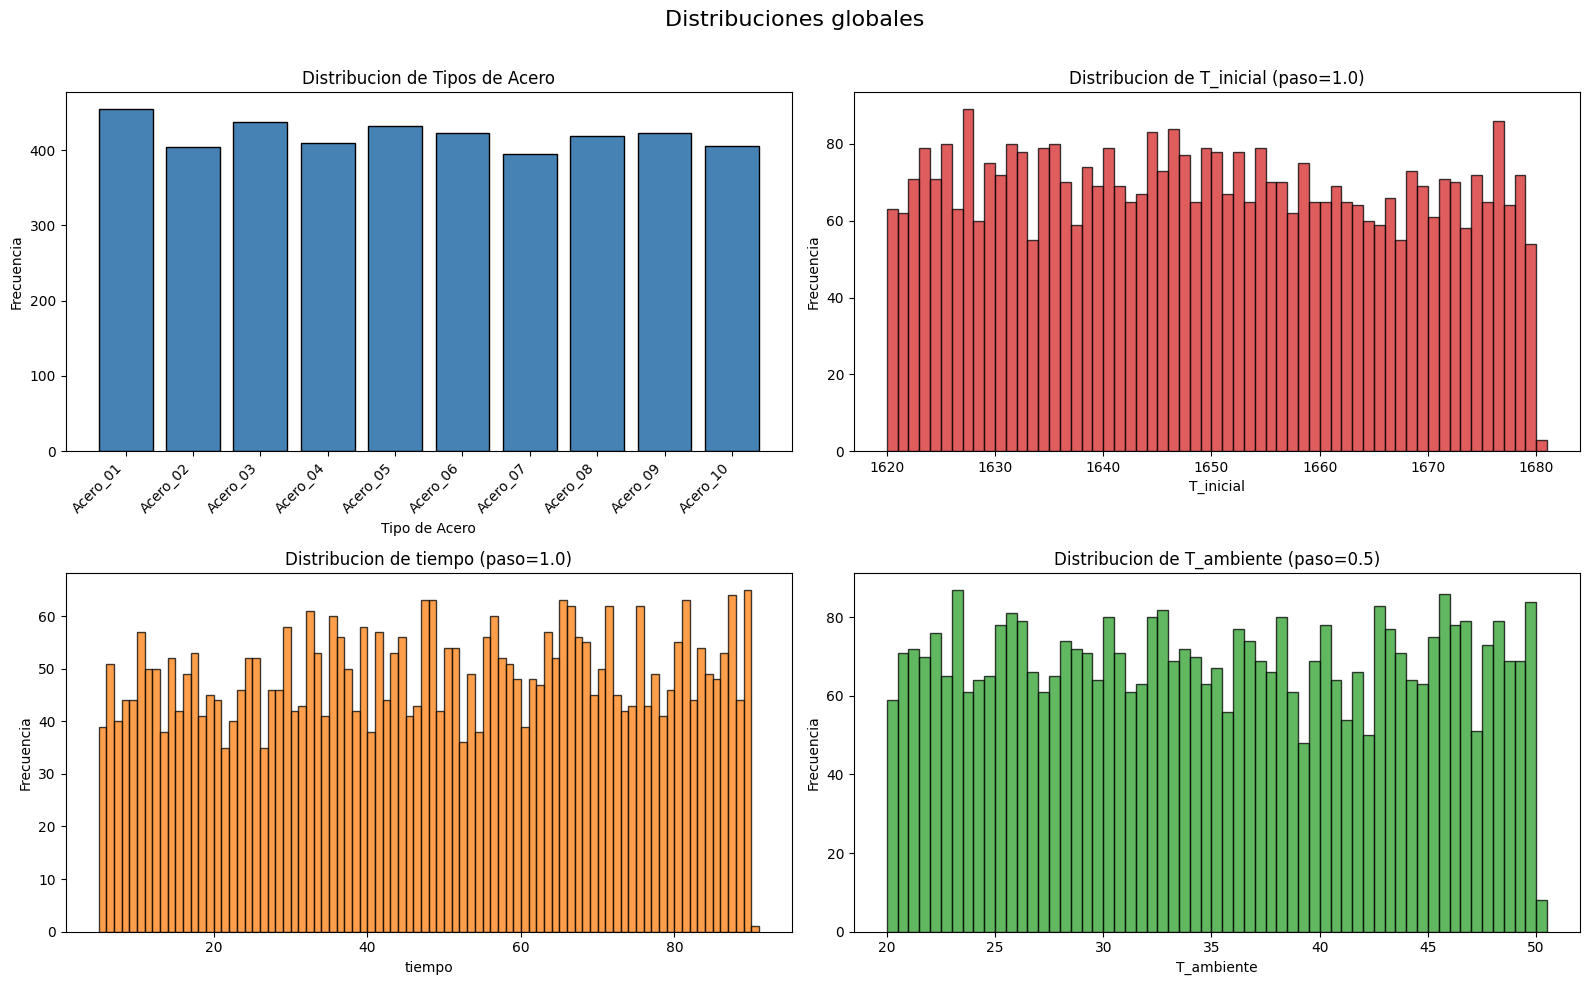

Tipos de acero y su distribucion:
tipo_acero
Acero_01    454
Acero_02    404
Acero_03    437
Acero_04    410
Acero_05    432
Acero_06    422
Acero_07    395
Acero_08    419
Acero_09    422
Acero_10    405
Name: count, dtype: int64

Resumen estadistico (global):


,variable,columna,paso_bin,min,max,media,std,n
0,T_inicial,T_inicial,1.0,1620.0,1680.0,1649.436429,17.205732,4200
1,tiempo,t_proceso,1.0,5.1,90.0,48.567857,24.423119,4200
2,T_ambiente,T_ambiente,0.5,20.0,50.0,35.013214,8.748624,4200


In [3]:
# Estudio individual global y distribucion de tipo de acero en una sola figura (4 axes)
os.makedirs('./img', exist_ok=True)

# 1) Distribucion del acero (tipo_acero)
tipos_acero = data['tipo_acero'].astype(str).str.strip().value_counts()
tipos_acero_ordenados = tipos_acero.sort_index()

# 2) Distribucion individual global
# Nota: t_proceso se etiqueta como "tiempo"
def encontrar_columna(df, candidatos, modo='exacto'):
    if modo == 'exacto':
        for c in candidatos:
            if c in df.columns:
                return c
    if modo == 'proceso':
        for c in df.columns:
            c_norm = c.lower().replace('_', '').replace(' ', '')
            if 'tproceso' in c_norm or c_norm.endswith('proceso') or 'proceso' in c_norm:
                return c
    return None

col_t_inicial = encontrar_columna(data, ['T_inicial', 'T_inical', 'T_inicial '], modo='exacto')
col_t_proceso = encontrar_columna(data, [], modo='proceso')
col_t_ambiente = encontrar_columna(data, ['T_ambiente', 'T ambiente', 'T_amb'], modo='exacto')

if col_t_inicial is None or col_t_proceso is None or col_t_ambiente is None:
    print('Columnas disponibles:', list(data.columns))
    raise ValueError('No se encontraron todas las columnas para el analisis individual global.')

cfg = [
    (col_t_inicial, 1.0, 'T_inicial', '#d62728'),
    (col_t_proceso, 1.0, 'tiempo', '#ff7f0e'),
    (col_t_ambiente, 0.5, 'T_ambiente', '#2ca02c'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

# Subplot 1: acero
x = np.arange(len(tipos_acero_ordenados.index))
axes[0].bar(x, tipos_acero_ordenados.values, color='steelblue', edgecolor='black')
axes[0].set_title('Distribucion de Tipos de Acero')
axes[0].set_xlabel('Tipo de Acero')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticks(x)
axes[0].set_xticklabels(tipos_acero_ordenados.index, rotation=45, ha='right')

# Subplots 2-4: variables individuales
resumen = []
for i, (col, paso, etiqueta, color) in enumerate(cfg, start=1):
    valores = data[col].astype(float).dropna().to_numpy()

    vmin = np.floor(valores.min() / paso) * paso
    vmax = np.ceil(valores.max() / paso) * paso + paso
    bins = np.arange(vmin, vmax + 1e-12, paso)

    axes[i].hist(valores, bins=bins, edgecolor='black', alpha=0.75, color=color)
    axes[i].set_title(f'Distribucion de {etiqueta} (paso={paso})')
    axes[i].set_xlabel(etiqueta)
    axes[i].set_ylabel('Frecuencia')

    resumen.append({
        'variable': etiqueta,
        'columna': col,
        'paso_bin': paso,
        'min': float(np.min(valores)),
        'max': float(np.max(valores)),
        'media': float(np.mean(valores)),
        'std': float(np.std(valores)),
        'n': int(valores.size),
    })

fig.suptitle('Distribuciones globales', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.97])

ruta_figura = './img/Distribucion_global_4axes.png'
fig.savefig(ruta_figura, dpi=300, bbox_inches='tight')
print(f'Imagen guardada en: {ruta_figura}')
plt.show()

# 1) Distribucion del acero (tipo_acero)
tipos_acero = data['tipo_acero'].astype(str).str.strip().value_counts()
tipos_acero_ordenados = tipos_acero.sort_index()

print('Tipos de acero y su distribucion:')
print(tipos_acero_ordenados)

resumen_df = pd.DataFrame(resumen)
print('\nResumen estadistico (global):')
display(resumen_df)

### ***Estudio de los datos para el acero***

Imagen guardada en: ./img/Distribucion_T_inicial_por_tipo_acero.png


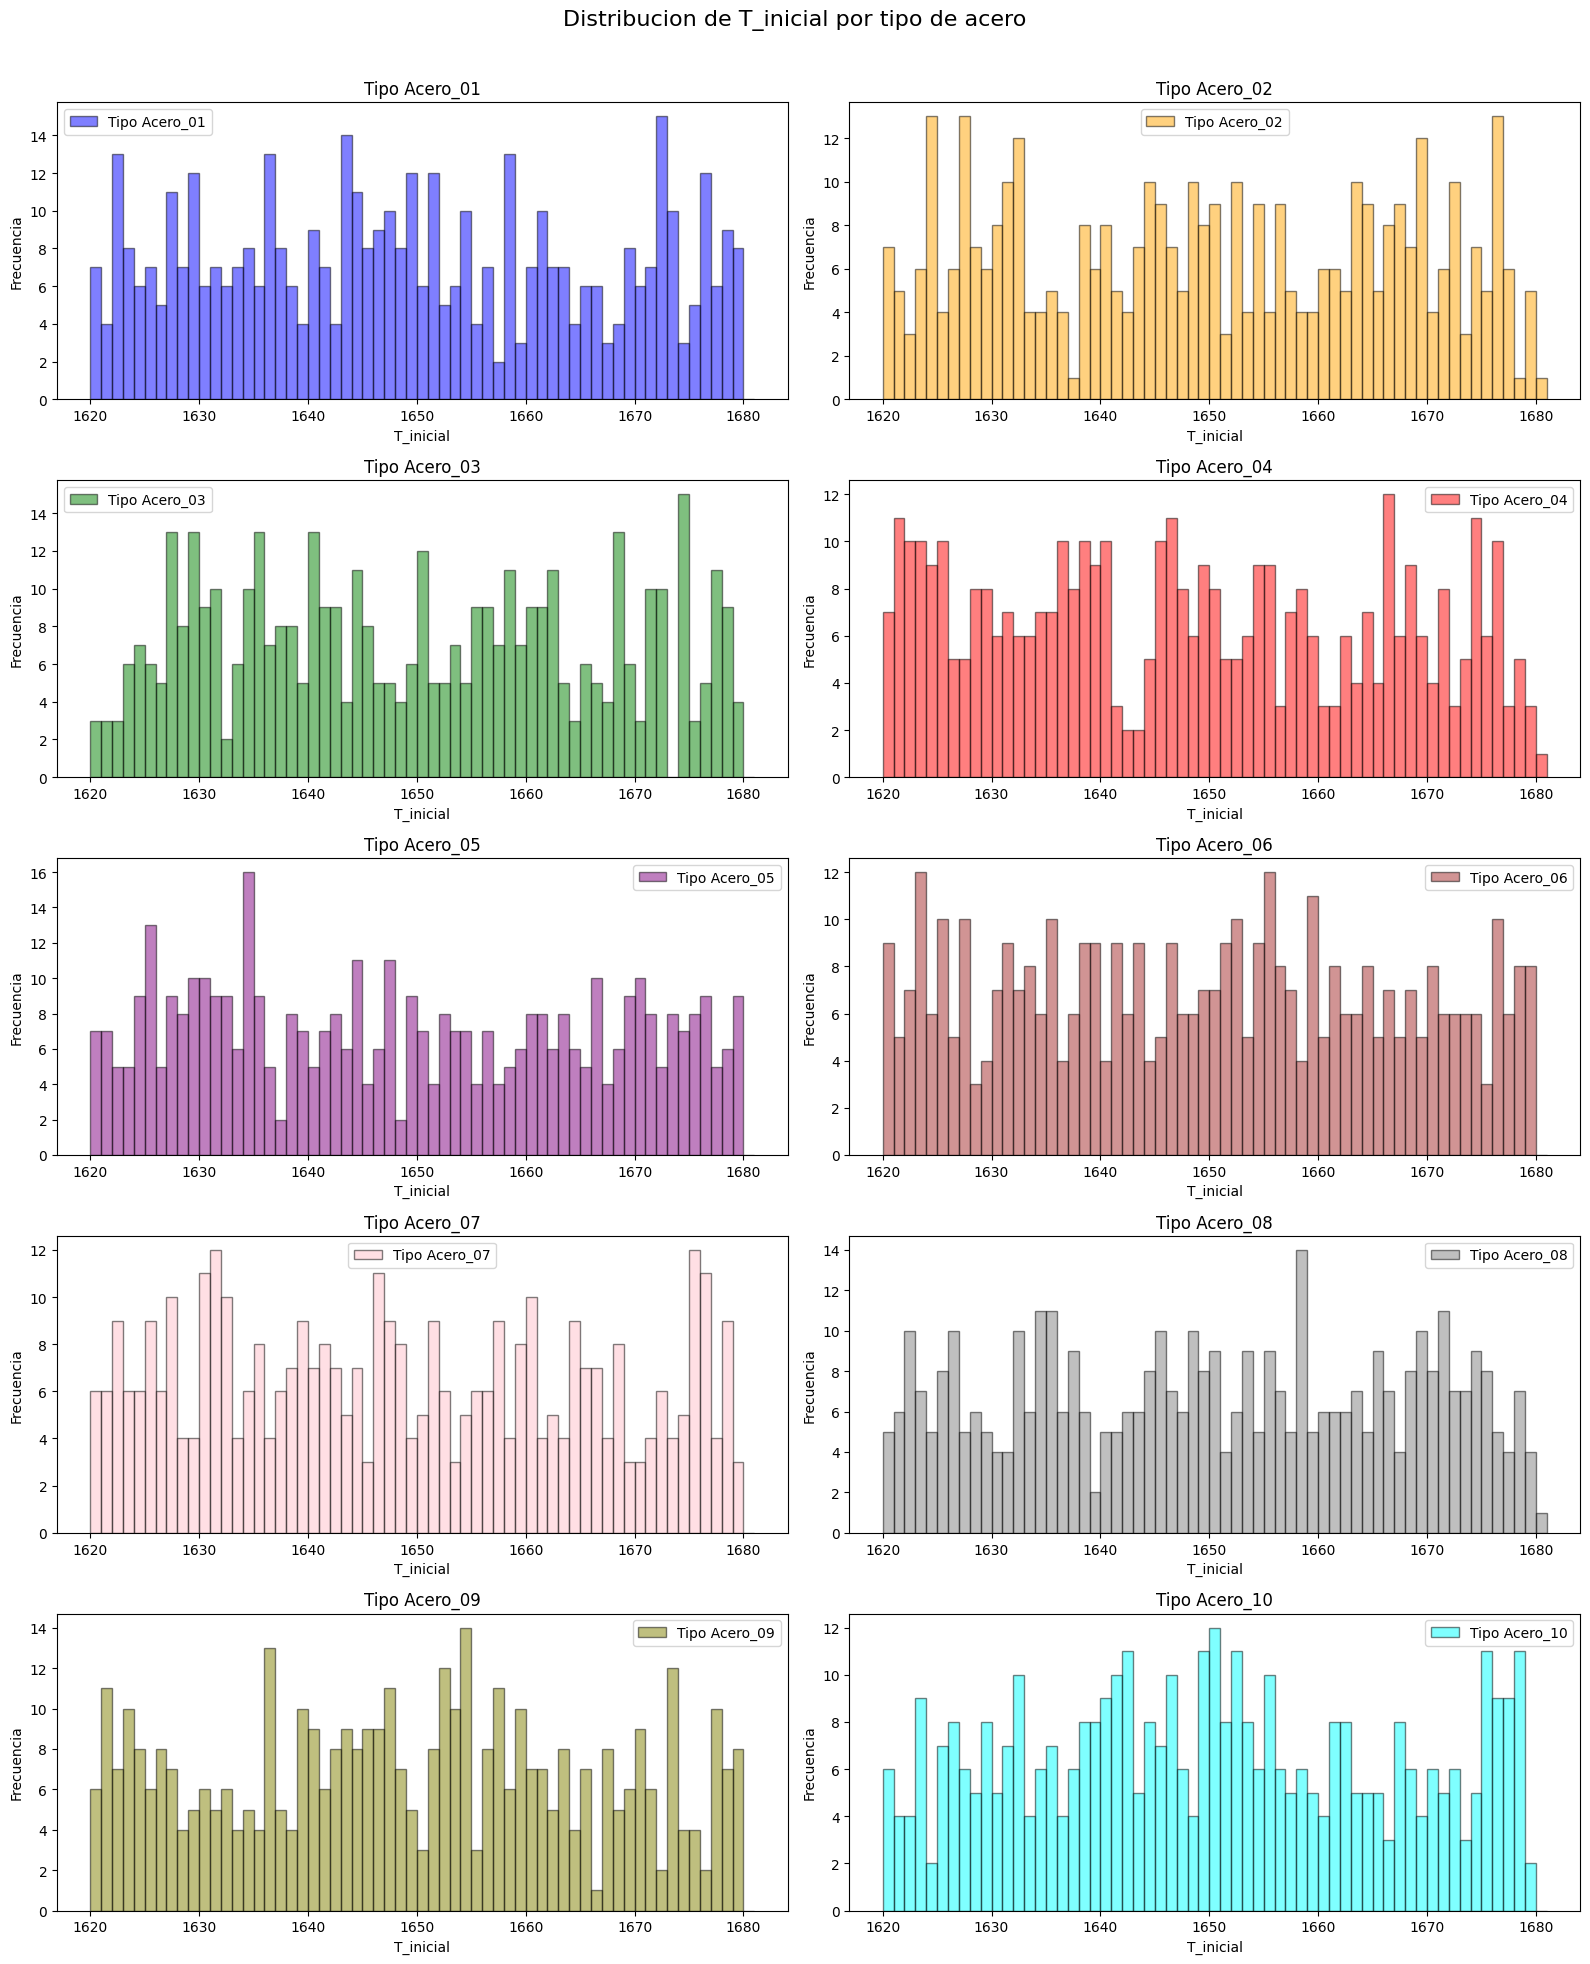

Imagen guardada en: ./img/Distribucion_T_proceso_por_tipo_acero.png


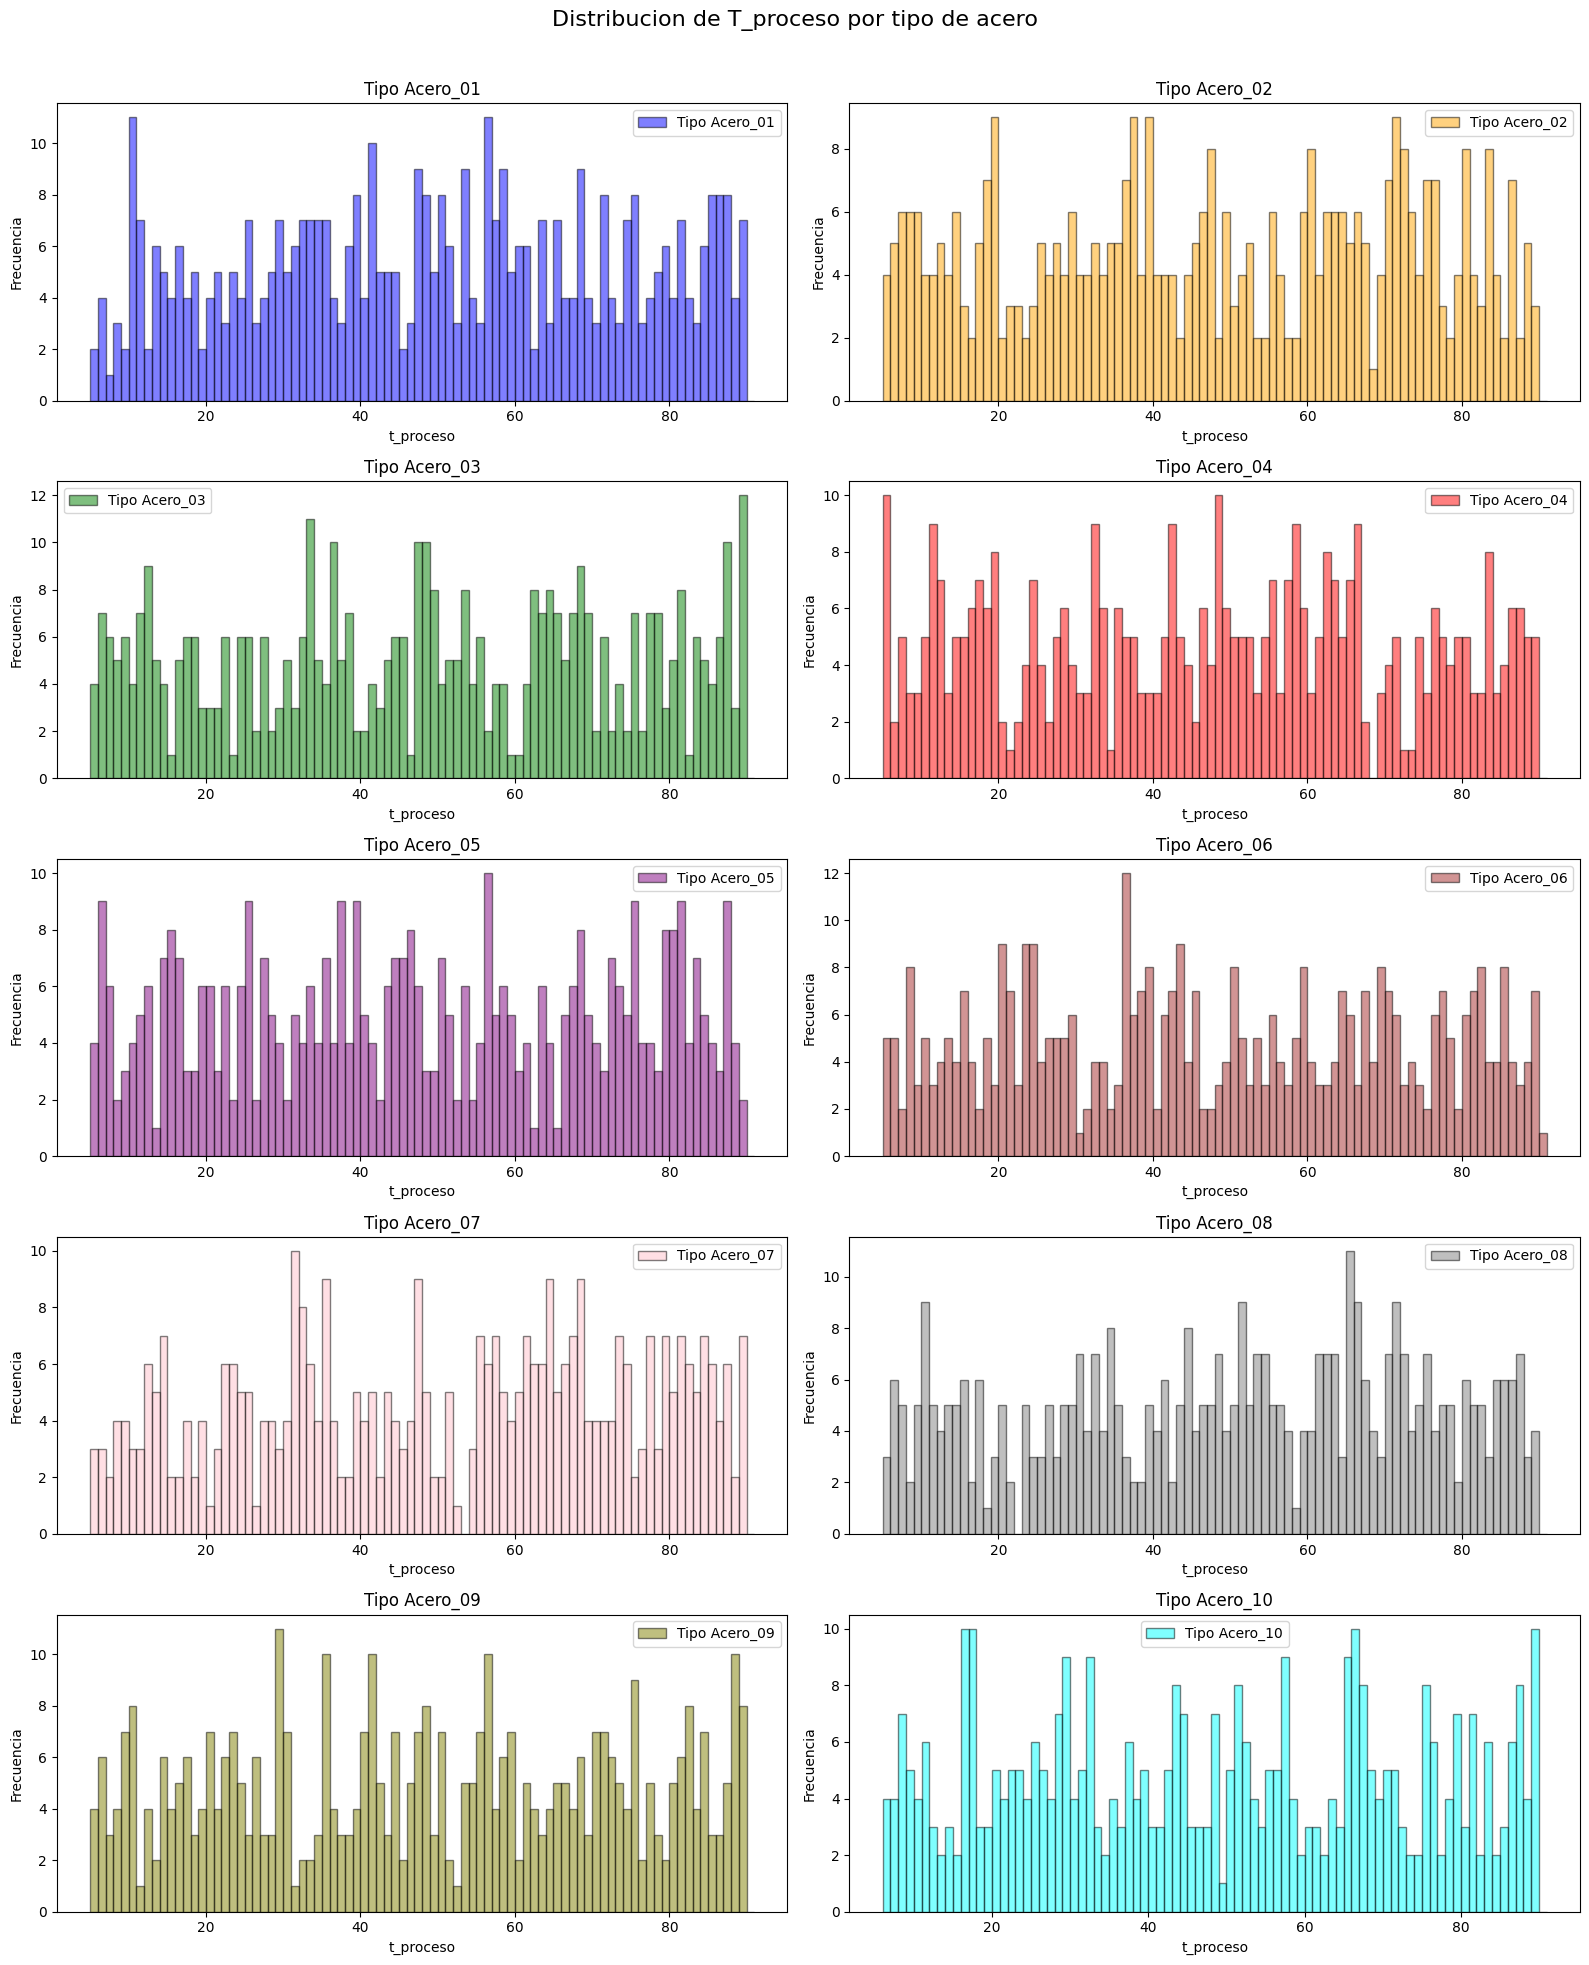

Imagen guardada en: ./img/Distribucion_T_ambiente_por_tipo_acero.png


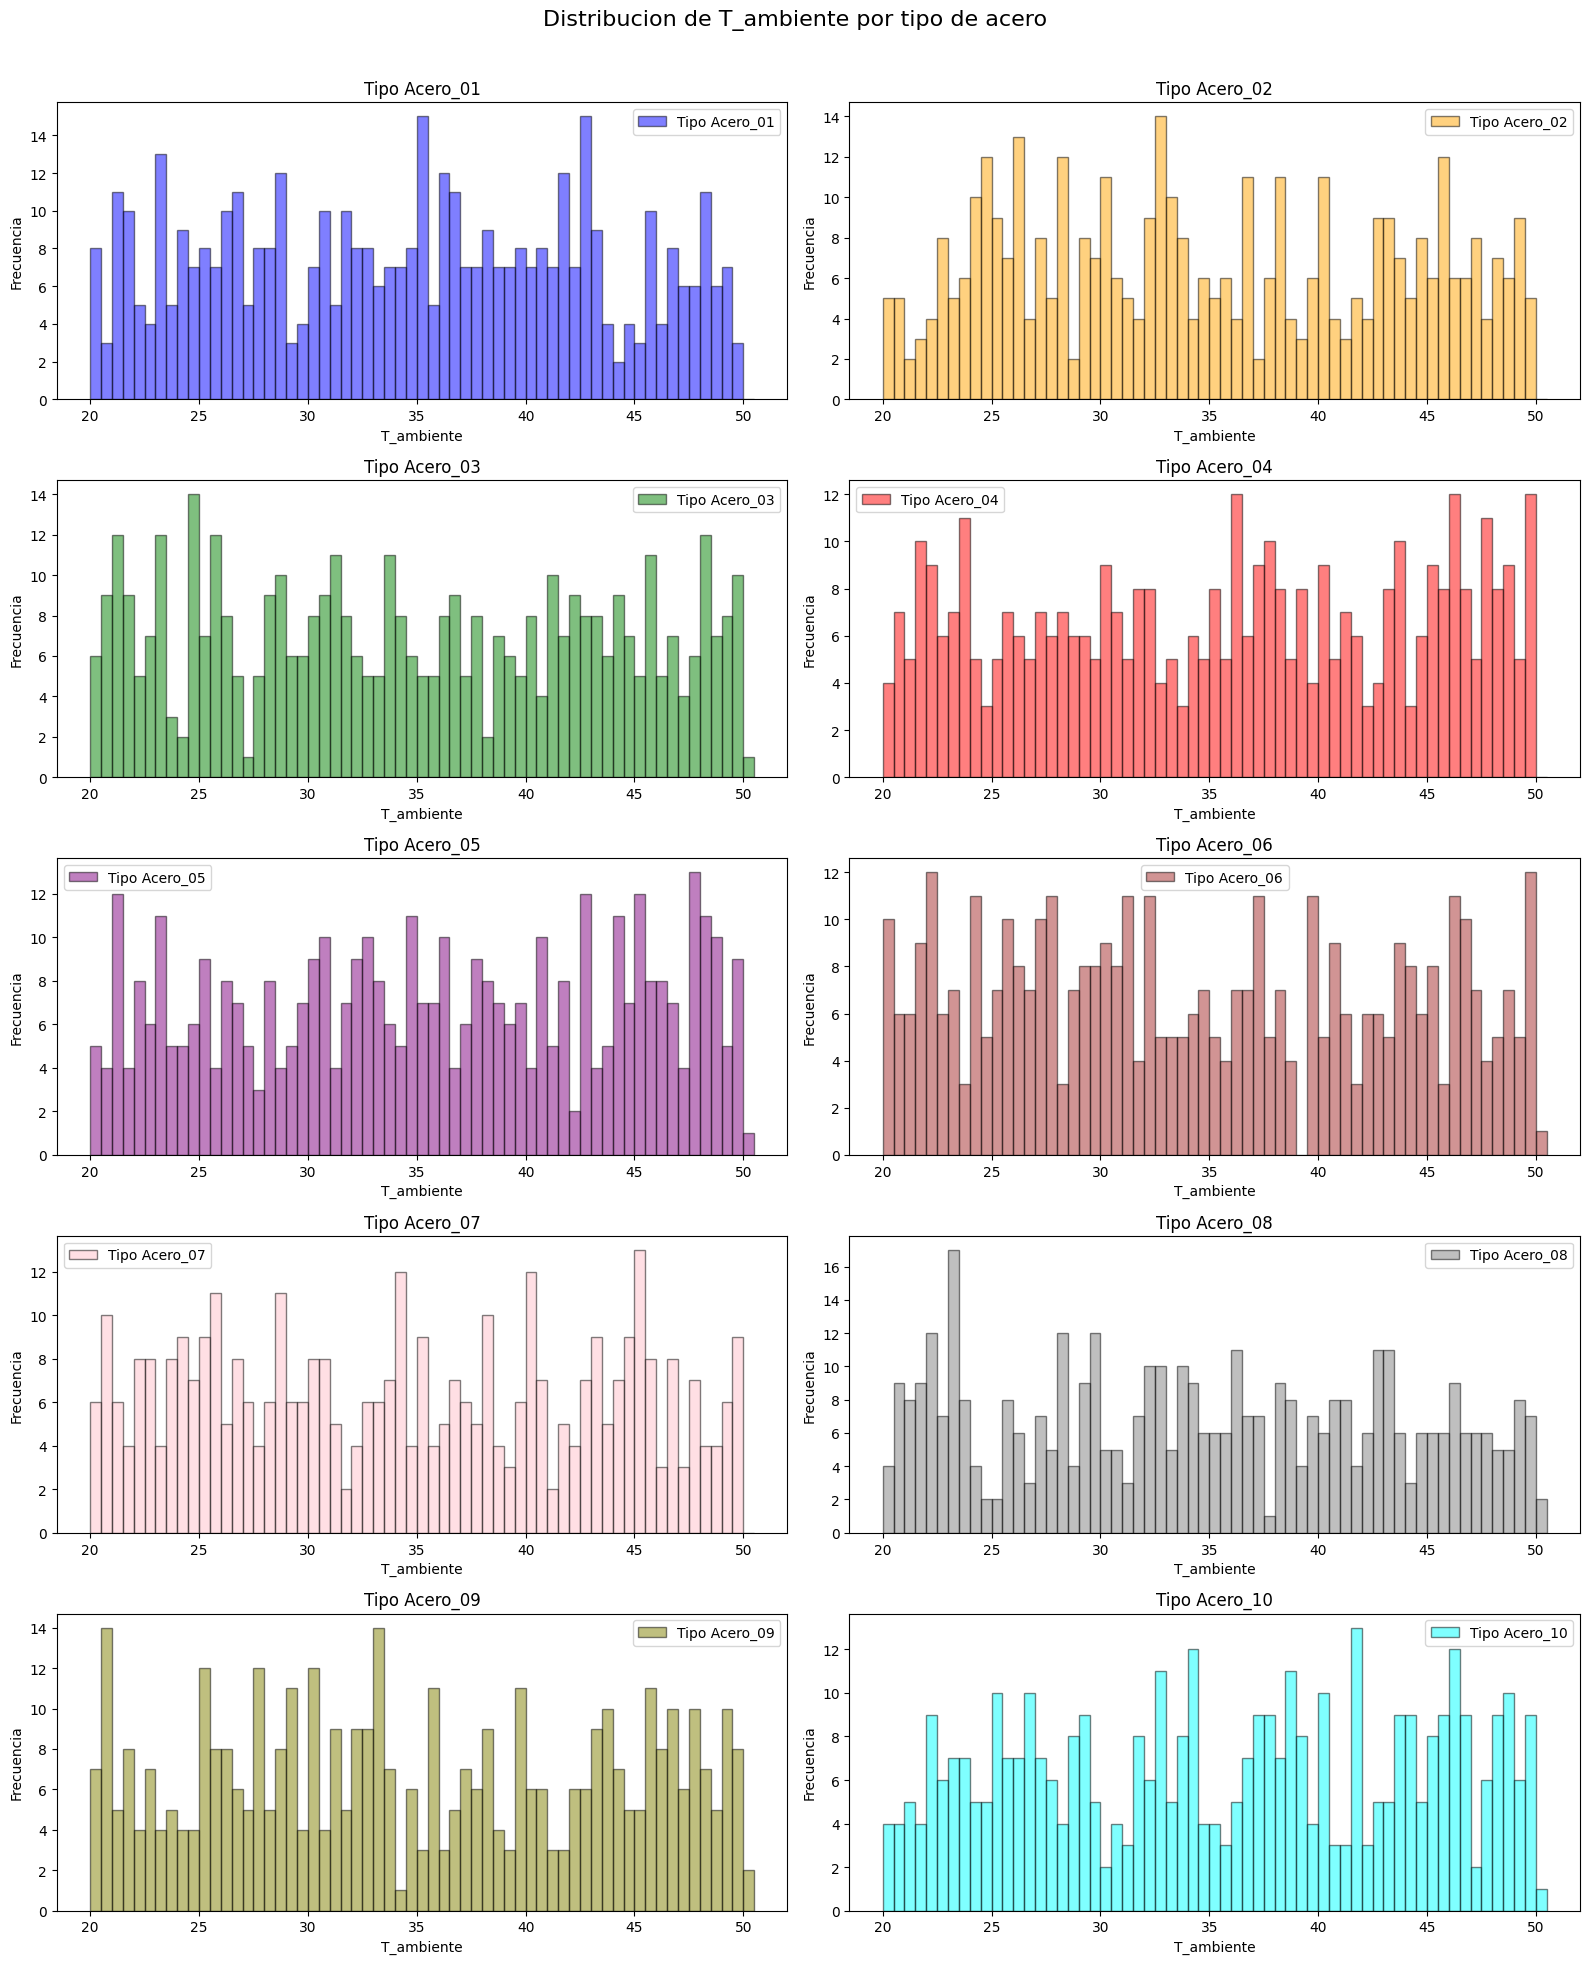

In [4]:
# Distribuciones por tipo de acero para T_inicial, t_proceso y T_ambiente
os.makedirs('./img', exist_ok=True)

def encontrar_columna(df, candidatos, modo='exacto'):
    if modo == 'exacto':
        for c in candidatos:
            if c in df.columns:
                return c
    if modo == 'proceso':
        for c in df.columns:
            c_norm = c.lower().replace('_', '').replace(' ', '')
            if 'tproceso' in c_norm or c_norm.endswith('proceso') or 'proceso' in c_norm:
                return c
    return None

# Misma paleta por tipo usada en T_final
colores = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

def graficar_por_tipo(df, col_valor, paso, titulo_general, nombre_archivo):
    tipos_ordenados = sorted(df['tipo_acero'].astype(str).str.strip().unique())
    n_tipos = len(tipos_ordenados)
    n_cols = 2
    n_rows = int(np.ceil(n_tipos / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, tipo in enumerate(tipos_ordenados):
        subset = df[df['tipo_acero'].astype(str).str.strip() == tipo]
        valores = subset[col_valor].astype(float).dropna().to_numpy()

        if valores.size == 0:
            axes[i].set_title(f'Tipo {tipo} (sin datos)')
            axes[i].set_axis_off()
            continue

        vmin = np.floor(valores.min() / paso) * paso
        vmax = np.ceil(valores.max() / paso) * paso + paso
        bins = np.arange(vmin, vmax + 1e-12, paso)

        color_tipo = colores[i % len(colores)]
        axes[i].hist(
            valores,
            bins=bins,
            edgecolor='black',
            alpha=0.5,
            color=color_tipo,
            label=f'Tipo {tipo}'
        )
        axes[i].set_title(f'Tipo {tipo}')
        axes[i].set_xlabel(col_valor)
        axes[i].set_ylabel('Frecuencia')
        axes[i].legend()

    # Ocultar ejes vacios si sobran subplots
    for j in range(n_tipos, len(axes)):
        axes[j].set_axis_off()

    fig.suptitle(titulo_general, fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    ruta = f'./img/{nombre_archivo}'
    fig.savefig(ruta, dpi=300, bbox_inches='tight')
    print(f'Imagen guardada en: {ruta}')
    plt.show()

col_t_inicial = encontrar_columna(data, ['T_inicial', 'T_inical', 'T_inicial '], modo='exacto')
col_t_ambiente = encontrar_columna(data, ['T_ambiente', 'T ambiente', 'T_amb'], modo='exacto')
col_t_proceso = encontrar_columna(data, [], modo='proceso')

if col_t_inicial is None or col_t_ambiente is None or col_t_proceso is None:
    print('Columnas disponibles:', list(data.columns))
    raise ValueError('No se encontraron todas las columnas requeridas para las graficas por tipo de acero.')

graficar_por_tipo(
    data,
    col_t_inicial,
    paso=1.0,
    titulo_general='Distribucion de T_inicial por tipo de acero',
    nombre_archivo='Distribucion_T_inicial_por_tipo_acero.png'
 )

graficar_por_tipo(
    data,
    col_t_proceso,
    paso=1,
    titulo_general='Distribucion de T_proceso por tipo de acero',
    nombre_archivo='Distribucion_T_proceso_por_tipo_acero.png'
 )

graficar_por_tipo(
    data,
    col_t_ambiente,
    paso=0.5,
    titulo_general='Distribucion de T_ambiente por tipo de acero',
    nombre_archivo='Distribucion_T_ambiente_por_tipo_acero.png'
 )

## ***Estudio de la variable objetivo***

### ***Vista general de T_final y su forma***

Rango de T_final: 1457.0 a 1679.3
Cantidad de valores únicos: 1528
Cantidad de valores únicos esperados: 2223
Imagen guardada en: ./img/Distribucion_T_final.png


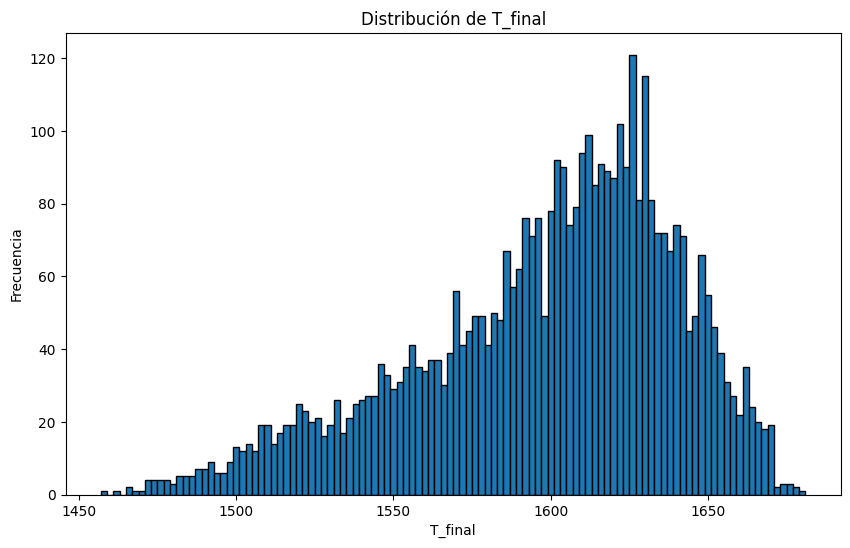

In [5]:
valores = data['T_final'].value_counts()

# Ordenar valores por temperatura
valores_ordenados = valores.sort_index()

# Valores únicos de T_final y rango
min = data['T_final'].min()
max = data['T_final'].max()

print(f"Rango de T_final: {min} a {max}")
print(f"Cantidad de valores únicos: {len(valores_ordenados)}")
print(f"Cantidad de valores únicos esperados: {10 * (max - min):.0f}")

# Distribución de T_final espaciado de 2
plt.figure(figsize=(10, 6))
plt.hist(data['T_final'], bins=np.arange(min, max + 2, 2), edgecolor='black')
plt.title('Distribución de T_final')
plt.xlabel('T_final')
plt.ylabel('Frecuencia')
ruta_t_final = './img/Distribucion_T_final.png'
plt.savefig(ruta_t_final, dpi=300, bbox_inches='tight')
print(f"Imagen guardada en: {ruta_t_final}")
plt.show()

### ***T_final con respecto al acero***

Imagen guardada en: ./img/Distribucion_T_final_Vs_acero.png


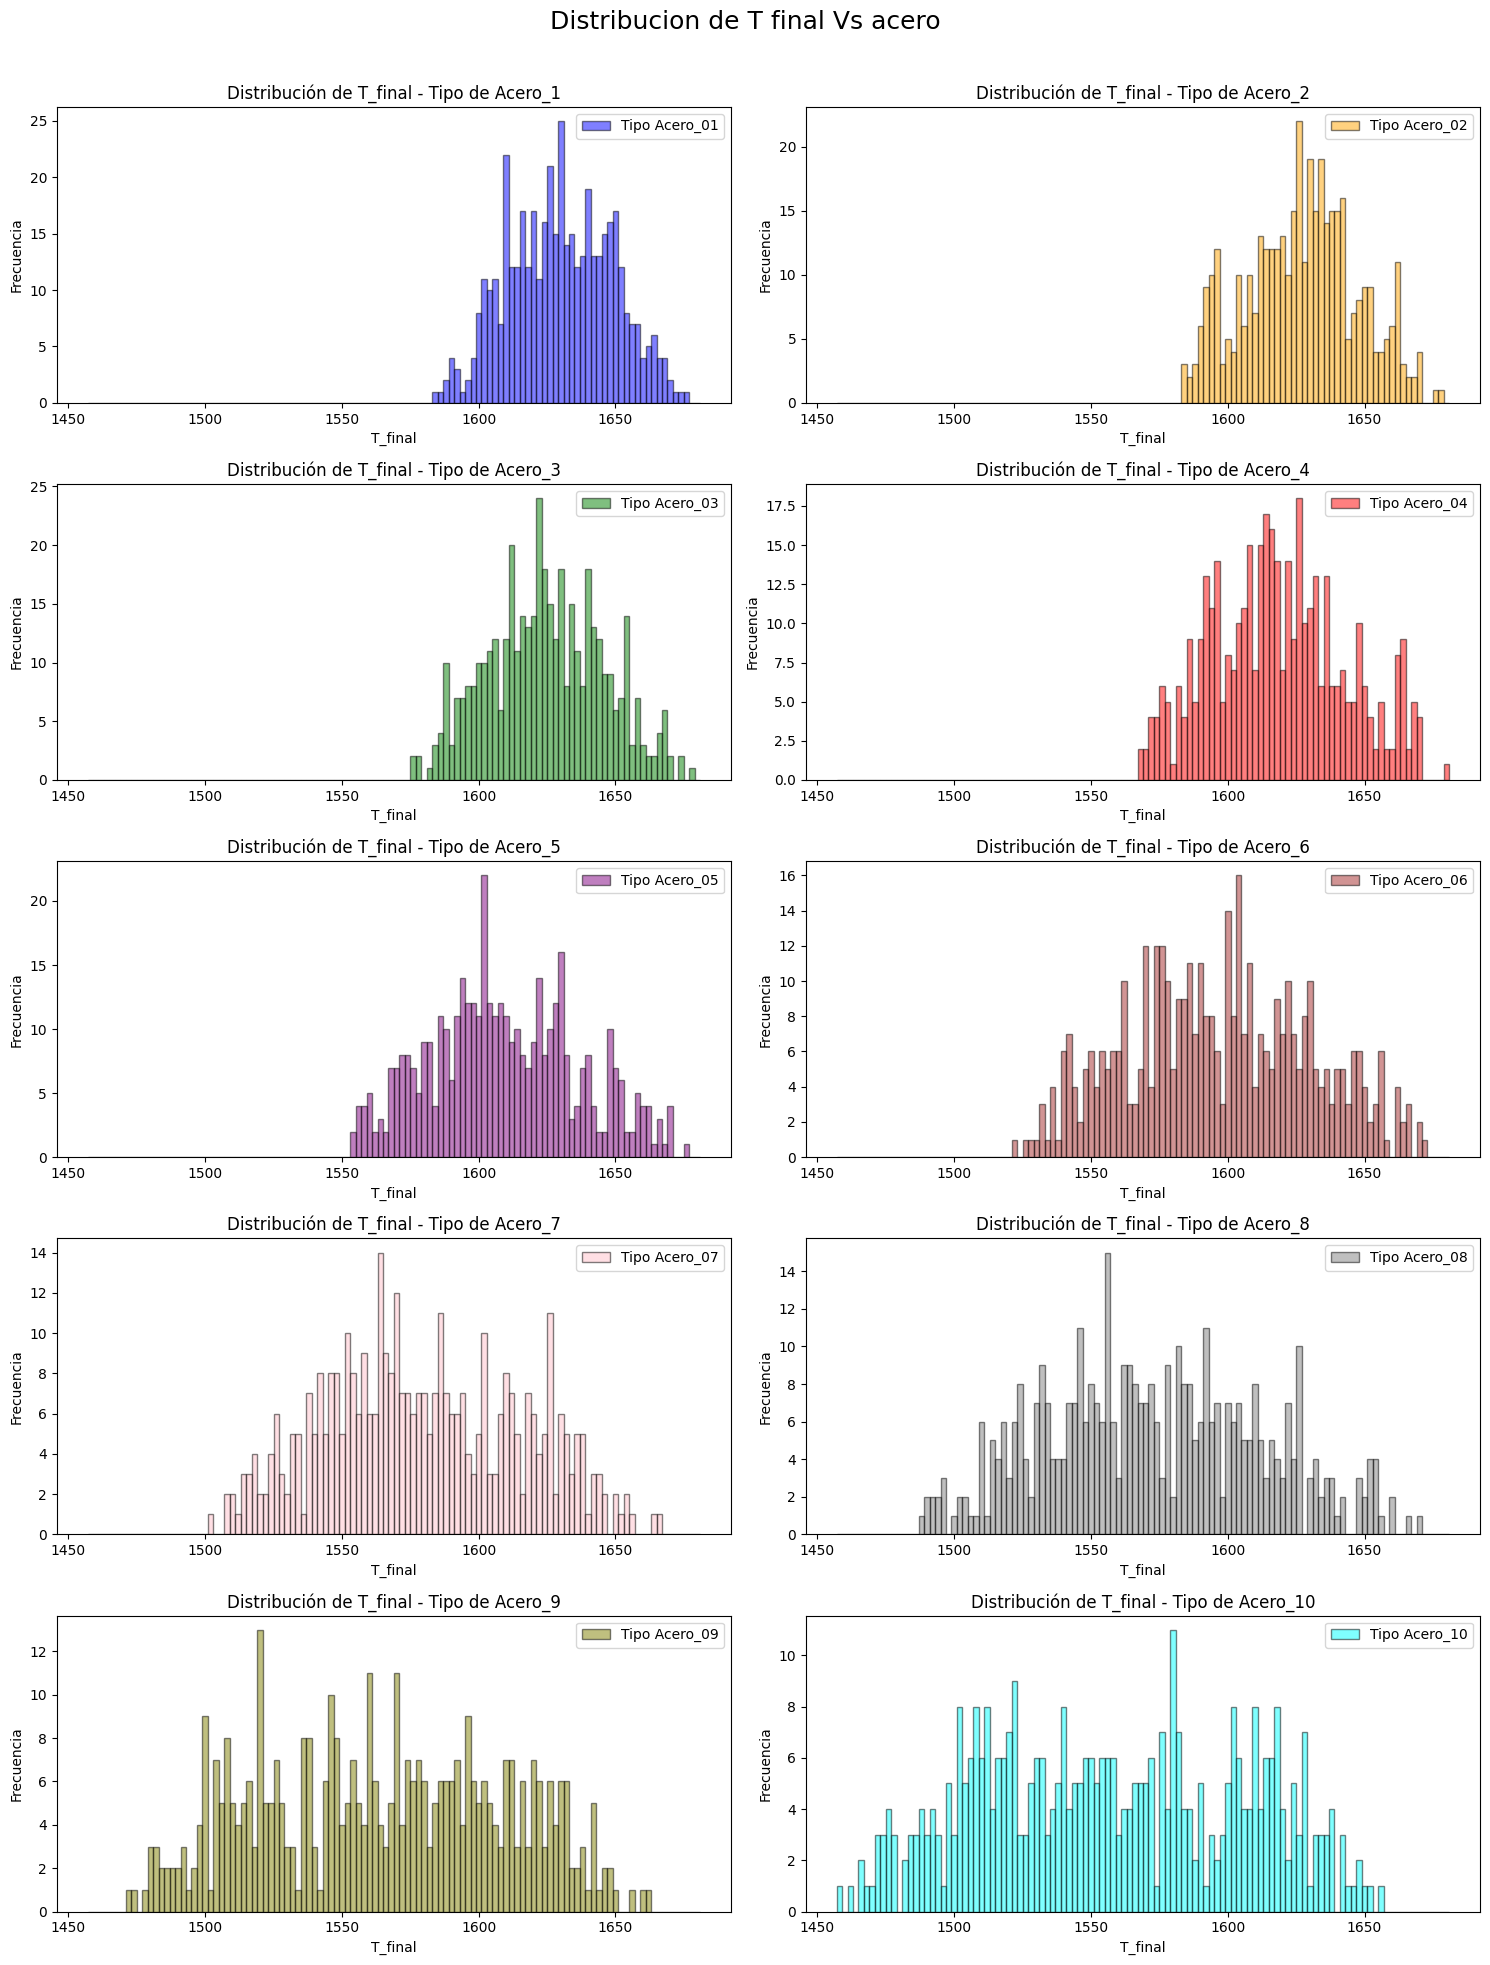

In [6]:

# Distribución de T_final por tipo de acero
colores = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
fig, ax = plt.subplots(5, 2, figsize=(15, 20))
ax = ax.flatten()

tipos_ordenados = sorted(data['tipo_acero'].unique())
for indice_mudo, tipo in enumerate(tipos_ordenados, start=1):
    subset = data[data['tipo_acero'] == tipo]
    ax[indice_mudo - 1].hist(
        subset['T_final'],
        bins=np.arange(min, max + 2, 2),
        alpha=0.5,
        label=f'Tipo {tipo}',
        edgecolor='black',
        color=colores[(indice_mudo - 1) % len(colores)]
    )
    ax[indice_mudo - 1].set_title(f'Distribución de T_final - Tipo de Acero_{indice_mudo}')
    ax[indice_mudo - 1].set_xlabel('T_final')
    ax[indice_mudo - 1].set_ylabel('Frecuencia')
    ax[indice_mudo - 1].legend()

fig.suptitle('Distribucion de T final Vs acero', fontsize=18)
fig.tight_layout(rect=[0, 0, 1, 0.97])
ruta_salida = './img/Distribucion_T_final_Vs_acero.png'
fig.savefig(ruta_salida, dpi=300, bbox_inches='tight')
print(f"Imagen guardada en: {ruta_salida}")
plt.show()

### ***Resto de datos visualizados con T_final***

Imagen guardada en: ./img/T_final_vs_tiempo_Tinicial_Tambiente.png


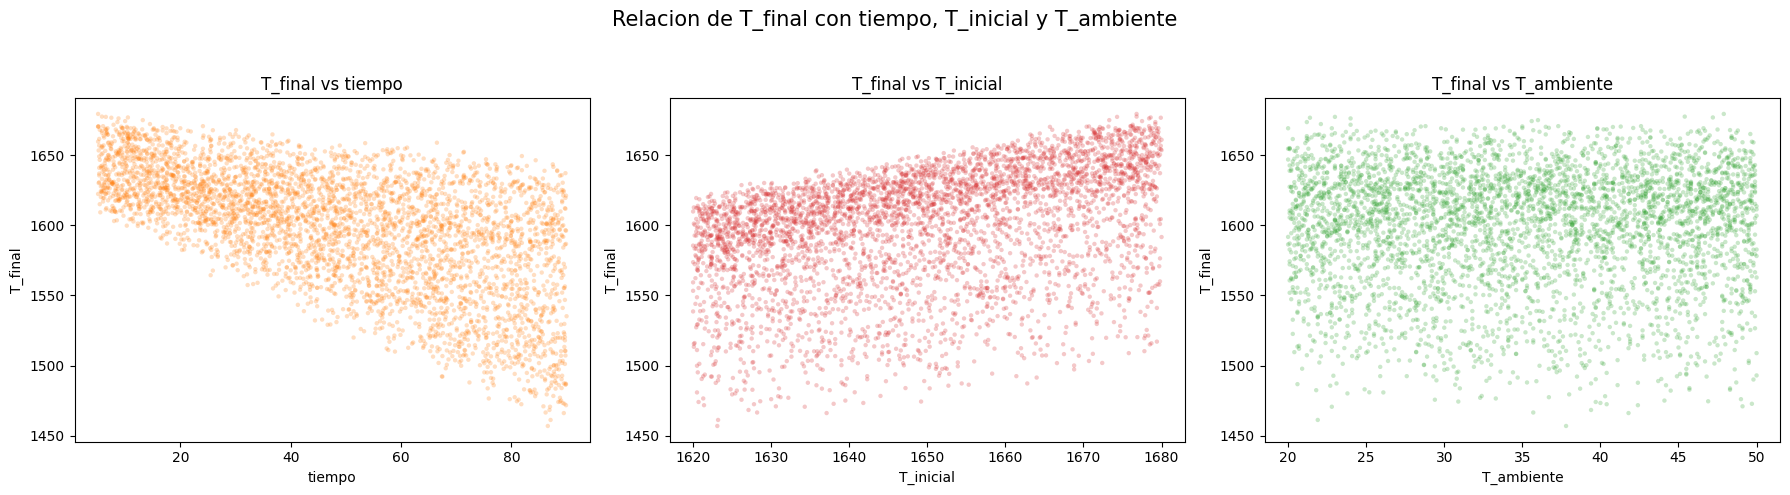

In [7]:
# Relacion de T_final con t_proceso, T_inicial y T_ambiente
os.makedirs('./img', exist_ok=True)

if 'encontrar_columna' not in globals():
    def encontrar_columna(df, candidatos, modo='exacto'):
        if modo == 'exacto':
            for c in candidatos:
                if c in df.columns:
                    return c
        if modo == 'proceso':
            for c in df.columns:
                c_norm = c.lower().replace('_', '').replace(' ', '')
                if 'tproceso' in c_norm or c_norm.endswith('proceso') or 'proceso' in c_norm:
                    return c
        return None

col_tfinal = encontrar_columna(data, ['T_final', 'T final', 'Tfinal'], modo='exacto')
col_ti = encontrar_columna(data, ['T_inicial', 'T_inical', 'T_inicial '], modo='exacto')
col_tp = encontrar_columna(data, [], modo='proceso')
col_ta = encontrar_columna(data, ['T_ambiente', 'T ambiente', 'T_amb'], modo='exacto')

if col_tfinal is None or col_ti is None or col_tp is None or col_ta is None:
    print('Columnas disponibles:', list(data.columns))
    raise ValueError('No se encontraron todas las columnas requeridas para graficar T_final.')

pairs = [
    (col_tp, 'tiempo', '#ff7f0e'),
    (col_ti, 'T_inicial', '#d62728'),
    (col_ta, 'T_ambiente', '#2ca02c'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

y = data[col_tfinal].astype(float).to_numpy()

for ax, (col_x, label_x, color) in zip(axes, pairs):
    x = data[col_x].astype(float).to_numpy()

    ax.scatter(x, y, s=10, alpha=0.25, color=color, edgecolors='none')
    ax.set_title(f'T_final vs {label_x}')
    ax.set_xlabel(label_x)
    ax.set_ylabel('T_final')

fig.suptitle('Relacion de T_final con tiempo, T_inicial y T_ambiente', fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.95])

ruta_rel = './img/T_final_vs_tiempo_Tinicial_Tambiente.png'
fig.savefig(ruta_rel, dpi=300, bbox_inches='tight')
print(f'Imagen guardada en: {ruta_rel}')
plt.show()

### ***Estudio termodinámico***


1) ANALISIS TERMODINAMICO (DELTA T)
Registros analizados: 4,200
Delta T global -> media: 51.16, mediana: 38.60, std: 38.82


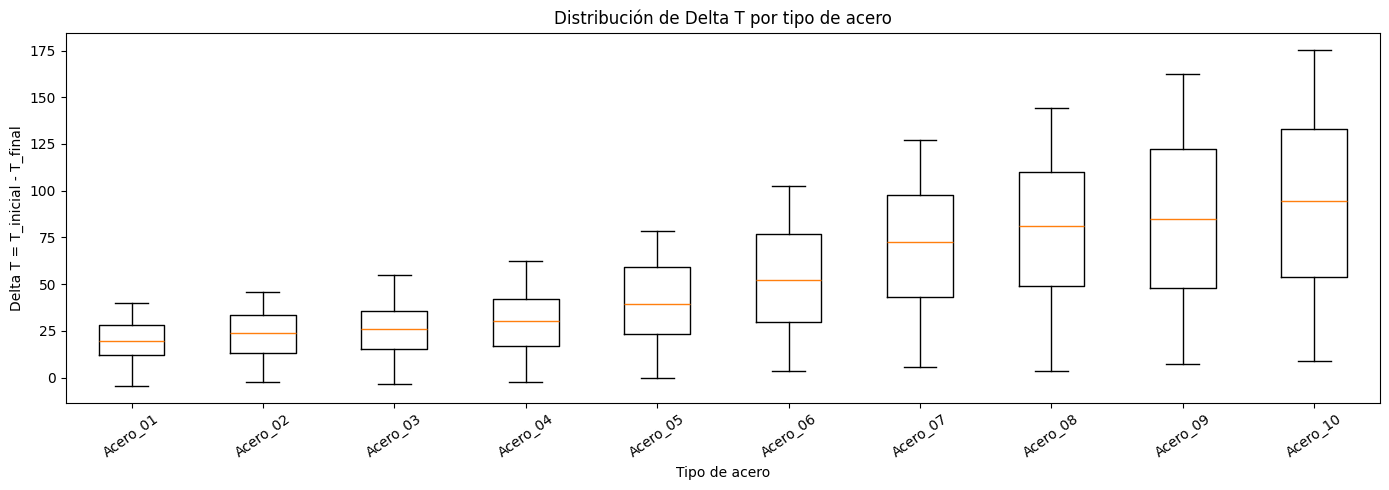


Resumen Delta T por tipo de acero (ordenado por media):


,count,mean,median,std,min,max
tipo_acero,,,,,,
Acero_01,454,19.731938,19.30,10.114882,-4.4,40.0
Acero_02,404,22.960644,23.70,12.372358,-2.4,45.9
Acero_03,437,25.498856,26.10,13.429783,-3.3,55.0
Acero_04,410,29.840000,30.20,15.831105,-2.5,62.4
Acero_05,432,40.255324,39.20,20.730399,-0.3,78.5
Acero_06,422,52.944076,52.15,26.991211,3.7,102.4
Acero_07,395,69.424810,72.70,32.403071,5.8,127.4
Acero_08,419,77.875418,81.30,37.457835,3.3,144.5
Acero_09,422,84.861848,84.95,42.476841,7.0,162.4


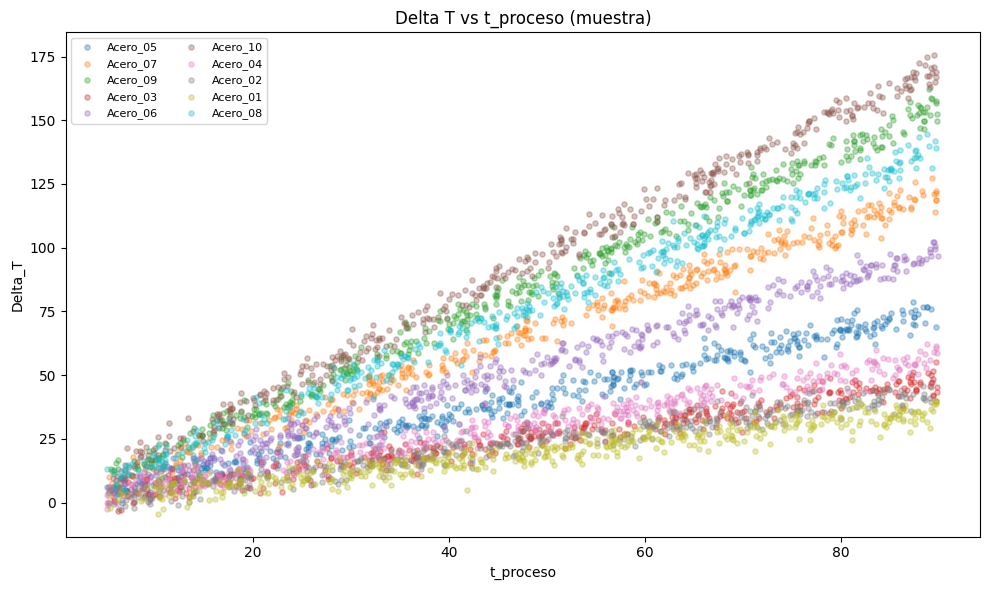

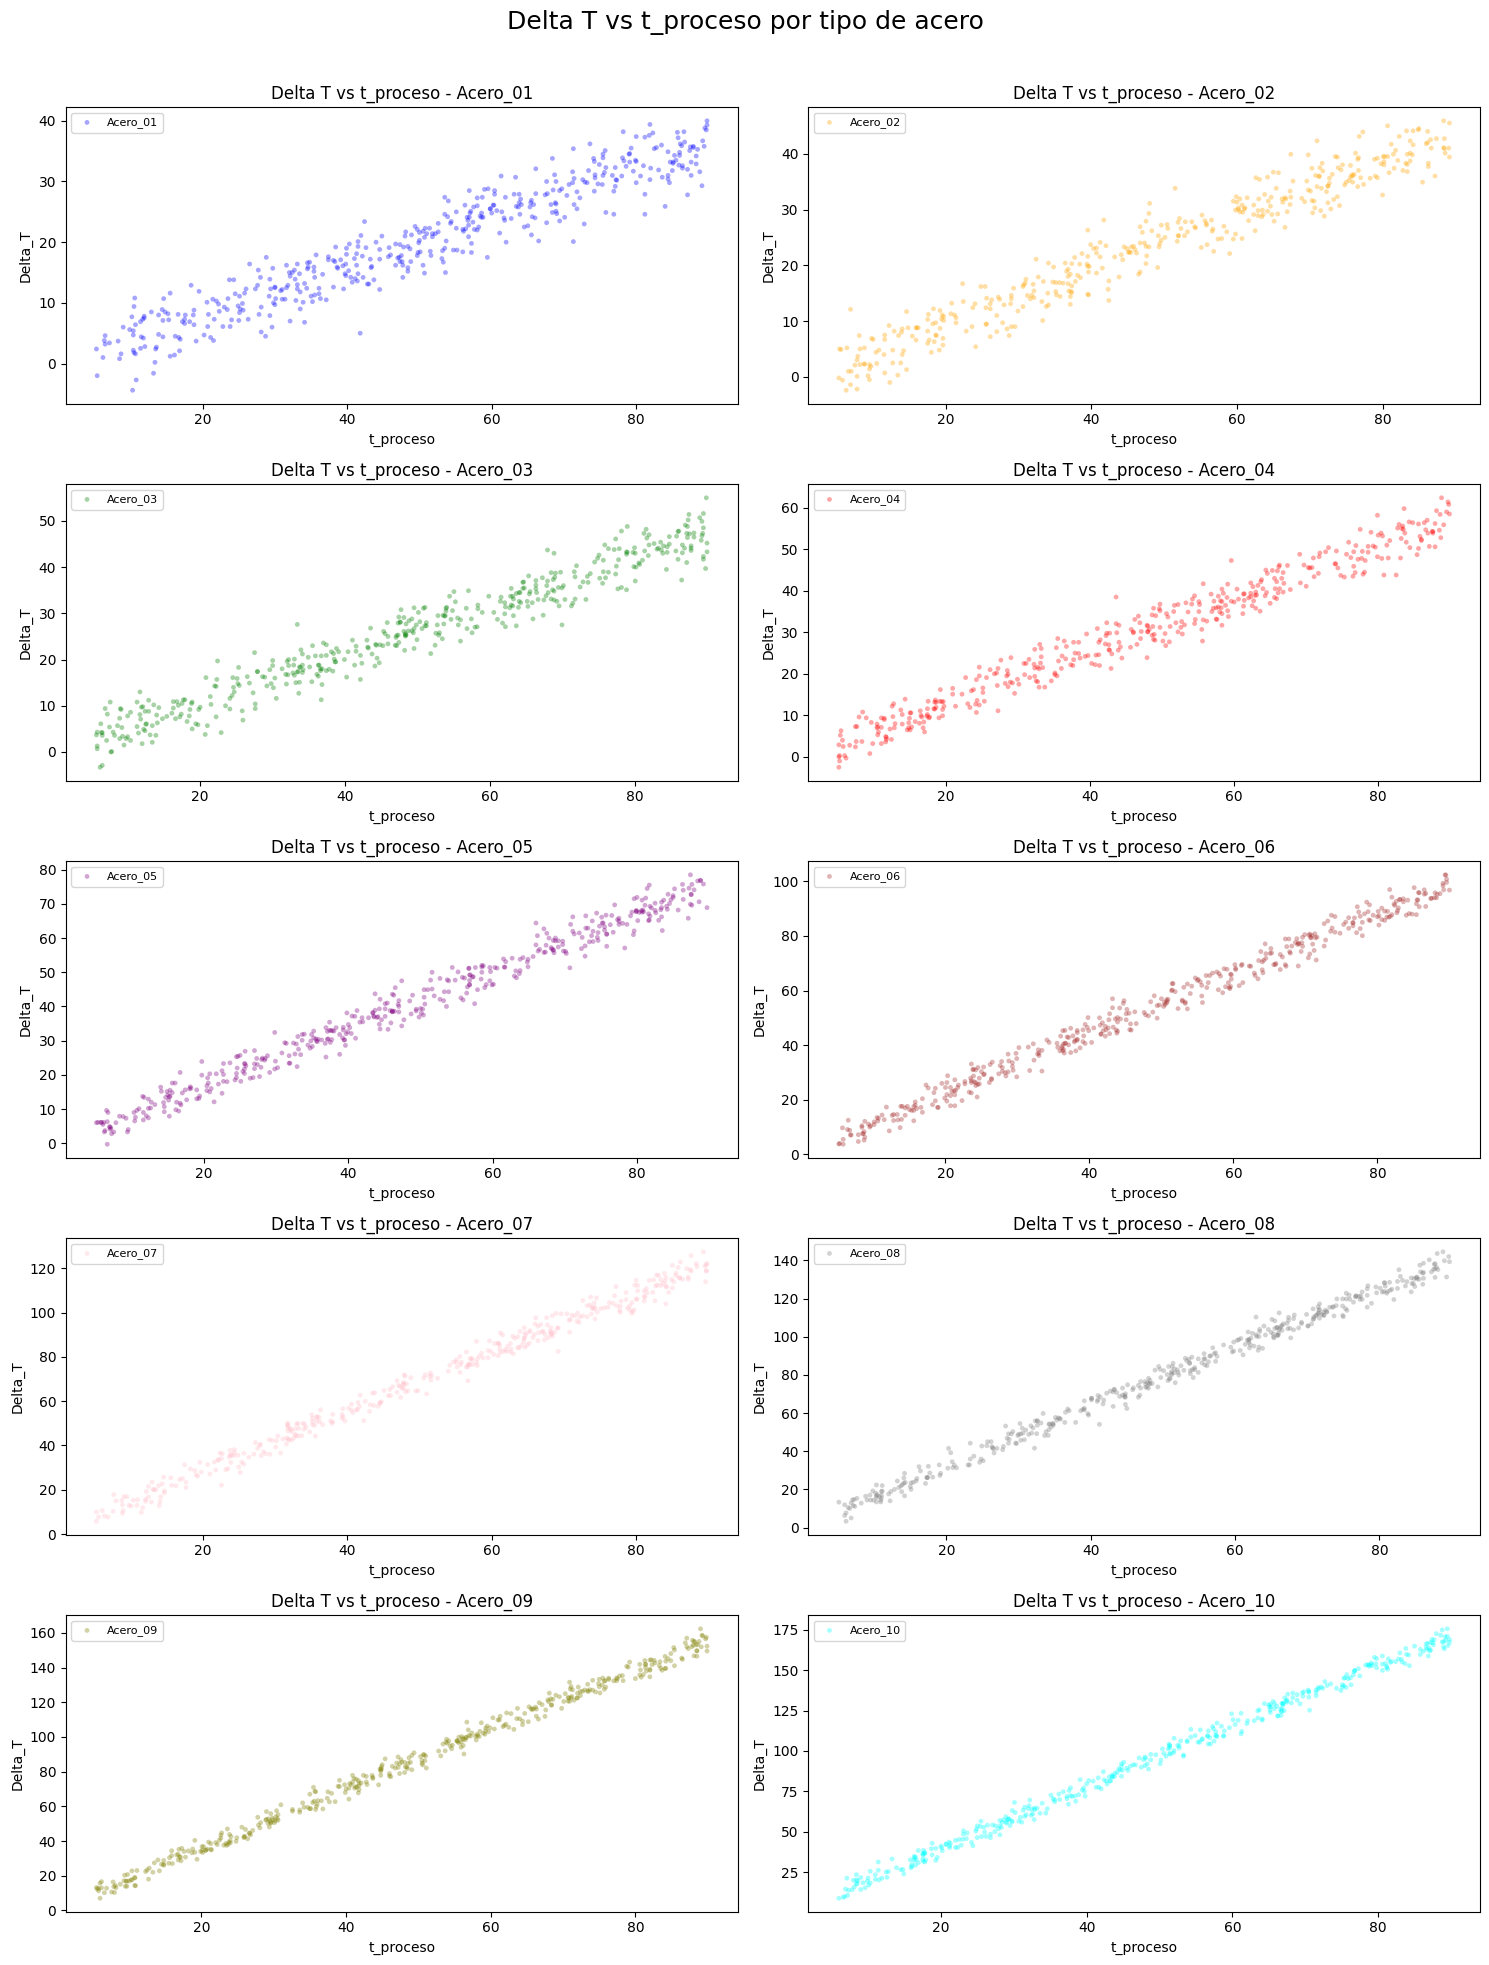


Registros con Delta T negativo (T_final > T_inicial): 19
     tipo_acero  T_inicial  T_final  Delta_T
27     Acero_03     1630.1   1630.1      0.0
223    Acero_02     1663.2   1664.6     -1.4
502    Acero_01     1665.7   1670.1     -4.4
907    Acero_02     1626.2   1628.6     -2.4
1161   Acero_02     1676.8   1677.4     -0.6
4) RELACION CON EL GRADIENTE AMBIENTAL
Pearson(Delta_T, Gradiente_amb):  0.0313
Spearman(Delta_T, Gradiente_amb): 0.0325
Pearson(Delta_T, t_proceso):      0.6610

Poder explicativo (R2 lineal):
R2 con Gradiente_amb solo: 0.0010
R2 con t_proceso solo:     0.4369
R2 con ambos:              0.4373

Correlaciones por tipo de acero:


,tipo_acero,pearson_grad,pearson_t_proceso
0,Acero_01,0.126779,0.954802
1,Acero_02,0.054344,0.971794
2,Acero_03,0.045936,0.973665
3,Acero_04,-0.020003,0.982173
4,Acero_05,0.042044,0.990037
5,Acero_06,-0.113682,0.993803
6,Acero_07,0.029224,0.994856
7,Acero_08,0.108992,0.996051
8,Acero_09,0.073673,0.997218
9,Acero_10,0.063813,0.997449


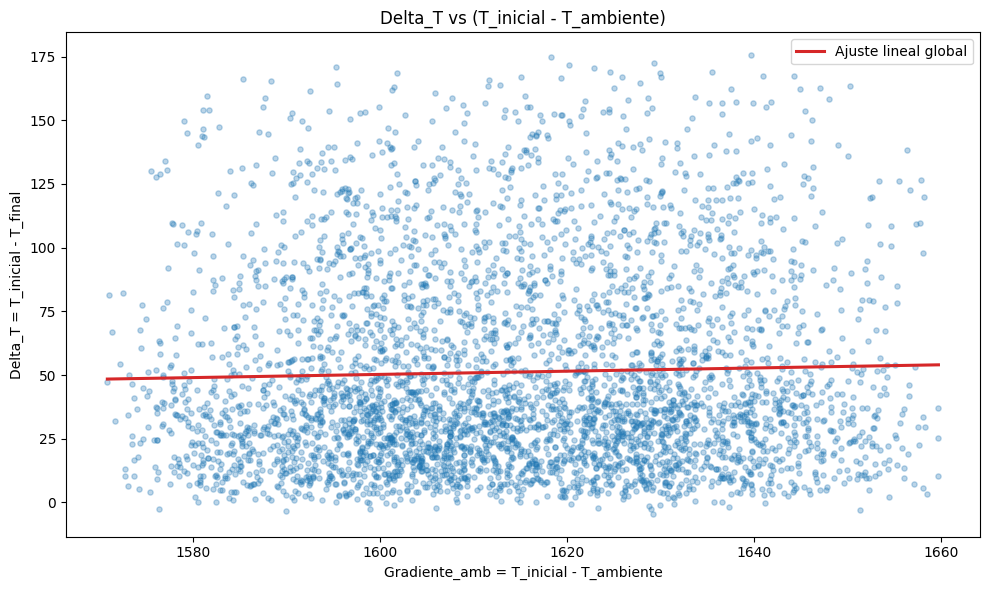


Conclusion automatica:
Evidencia de que domina mas el proceso/equipo (t_proceso) que el ambiente.
Imagen guardada en: ./img/T_final_vs_t_proceso_por_tipo_acero.png


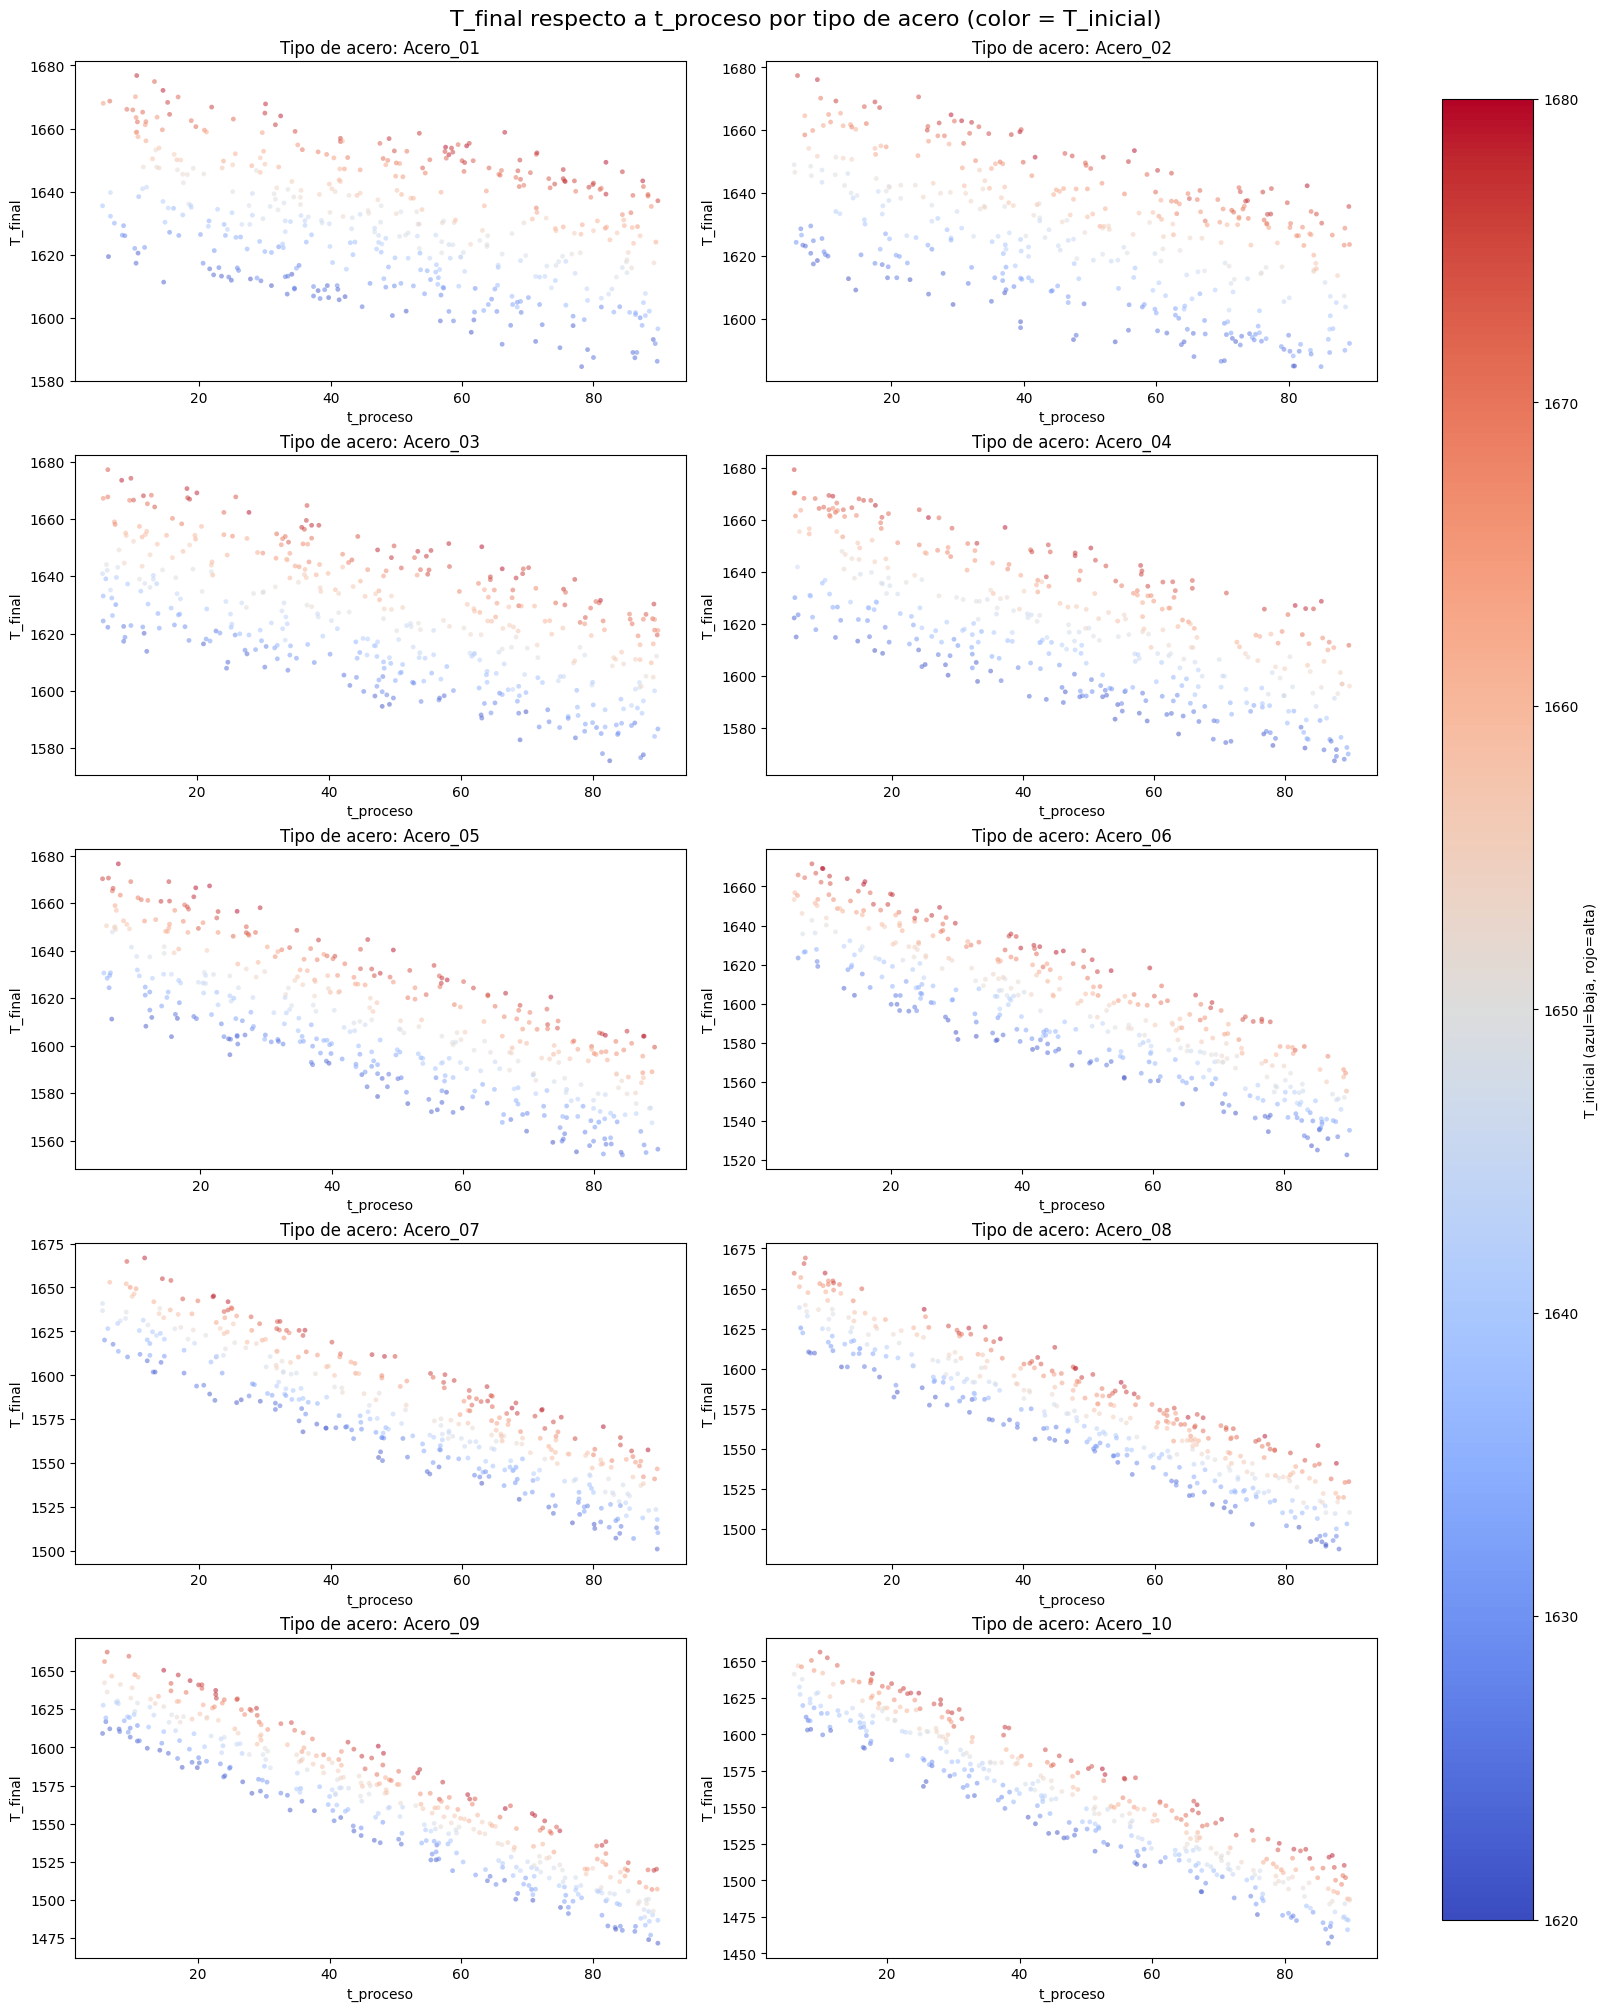

In [8]:
# Estilo para los graficos
plt.style.use('default')
os.makedirs('./img', exist_ok=True)

# --- 0) Validaciones y preparacion ---
# Asumiendo que tu dataframe original se llama 'data'
required_cols = ['tipo_acero', 'T_inicial', 'T_ambiente', 't_proceso', 'T_final']
missing_cols = [c for c in required_cols if c not in data.columns]
if missing_cols:
    raise ValueError(f"Faltan columnas para el analisis: {missing_cols}. Columnas disponibles: {list(data.columns)}")

df = data[required_cols].copy()

# --- 1) Analisis del comportamiento termodinamico (Delta T) ---
df['Delta_T'] = df['T_inicial'] - df['T_final']

print("\n" + "="*80)
print("1) ANALISIS TERMODINAMICO (DELTA T)")
print("="*80)
print(f"Registros analizados: {len(df):,}")
print(f"Delta T global -> media: {df['Delta_T'].mean():.2f}, mediana: {df['Delta_T'].median():.2f}, std: {df['Delta_T'].std():.2f}")

# 1.1 Distribucion de Delta_T por tipo de acero (Boxplot)
plt.figure(figsize=(14, 5))
order_types = df.groupby('tipo_acero')['Delta_T'].median().sort_values().index
data_box = [df.loc[df['tipo_acero'] == t, 'Delta_T'].values for t in order_types]
plt.boxplot(data_box, tick_labels=order_types, showfliers=False)
plt.title('Distribución de Delta T por tipo de acero')
plt.xlabel('Tipo de acero')
plt.ylabel('Delta T = T_inicial - T_final')
plt.xticks(rotation=35)
plt.tight_layout()
plt.savefig('./img/Delta_T_por_tipo_acero_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# Resumen estadistico
summary_delta = (
    df.groupby('tipo_acero')['Delta_T']
      .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
      .sort_values('mean')
)
print("\nResumen Delta T por tipo de acero (ordenado por media):")
display(summary_delta)

# 1.2 Curvas de enfriamiento empiricas: Delta_T vs t_proceso (muestra global)
plt.figure(figsize=(10, 6))
sample_plot = df.sample(builtins.min(len(df), 6000), random_state=42)
for acero in sample_plot['tipo_acero'].unique():
    g = sample_plot[sample_plot['tipo_acero'] == acero]
    plt.scatter(g['t_proceso'], g['Delta_T'], alpha=0.35, s=14, label=acero)
plt.title('Delta T vs t_proceso (muestra)')
plt.xlabel('t_proceso')
plt.ylabel('Delta_T')
plt.legend(loc='best', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('./img/Delta_T_vs_t_proceso_muestra.png', dpi=300, bbox_inches='tight')
plt.show()

# 1.3 Subplots 5x2: Delta_T vs t_proceso por tipo de acero
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

# Restaurar paleta por tipo como en graficos anteriores
colores = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

tipos_ordenados = sorted(df['tipo_acero'].astype(str).str.strip().unique())
for i, tipo in enumerate(tipos_ordenados):
    g = df[df['tipo_acero'].astype(str).str.strip() == tipo]
    color_tipo = colores[i % len(colores)]
    axes[i].scatter(
        g['t_proceso'],
        g['Delta_T'],
        alpha=0.35,
        s=12,
        color=color_tipo,
        edgecolors='none',
        label=tipo
    )
    axes[i].set_title(f'Delta T vs t_proceso - {tipo}')
    axes[i].set_xlabel('t_proceso')
    axes[i].set_ylabel('Delta_T')
    axes[i].legend(loc='best', fontsize=8)

# Por robustez, ocultar ejes sobrantes si llegaran a existir
for j in range(len(tipos_ordenados), len(axes)):
    axes[j].set_axis_off()

fig.suptitle('Delta T vs t_proceso por tipo de acero', fontsize=18)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig('./img/Delta_T_vs_t_proceso_por_tipo_5x2.png', dpi=300, bbox_inches='tight')
plt.show()

# Datos anomalos: Delta_T negativo (T_final > T_inicial)
anomalos = df[df['Delta_T'] <= 0]
print(f"\nRegistros con Delta T negativo (T_final > T_inicial): {len(anomalos)}")
if not anomalos.empty:
    print(anomalos[['tipo_acero', 'T_inicial', 'T_final', 'Delta_T']].head())

# ======================================================
# Relacion Delta_T vs gradiente ambiental (T_inicial-T_ambiente)
# ======================================================

# Variables fisicas
if 'Delta_T' not in df.columns:
    df['Delta_T'] = df['T_inicial'] - df['T_final']

df['Gradiente_amb'] = df['T_inicial'] - df['T_ambiente']

# Correlaciones globales
corr_pearson = df['Delta_T'].corr(df['Gradiente_amb'], method='pearson')
corr_spearman = df['Delta_T'].corr(df['Gradiente_amb'], method='spearman')
corr_tp = df['Delta_T'].corr(df['t_proceso'], method='pearson')

print('='*80)
print('4) RELACION CON EL GRADIENTE AMBIENTAL')
print('='*80)
print(f"Pearson(Delta_T, Gradiente_amb):  {corr_pearson:.4f}")
print(f"Spearman(Delta_T, Gradiente_amb): {corr_spearman:.4f}")
print(f"Pearson(Delta_T, t_proceso):      {corr_tp:.4f}")

# Regresiones lineales para comparar poder explicativo
# y = Delta_T
# X1 = Gradiente_amb
# X2 = t_proceso

def r2_ols(y, X):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    X_design = np.c_[np.ones(len(X)), X]
    beta, *_ = np.linalg.lstsq(X_design, y, rcond=None)
    y_hat = X_design @ beta
    ss_res = np.sum((y - y_hat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    return 1 - ss_res / ss_tot

y = df['Delta_T'].to_numpy()
r2_grad = r2_ols(y, df[['Gradiente_amb']].to_numpy())
r2_proc = r2_ols(y, df[['t_proceso']].to_numpy())
r2_both = r2_ols(y, df[['Gradiente_amb', 't_proceso']].to_numpy())

print('\nPoder explicativo (R2 lineal):')
print(f'R2 con Gradiente_amb solo: {r2_grad:.4f}')
print(f'R2 con t_proceso solo:     {r2_proc:.4f}')
print(f'R2 con ambos:              {r2_both:.4f}')

# Correlacion por tipo para detectar heterogeneidad
corr_tipo = (
    df.groupby('tipo_acero')
      .apply(lambda g: pd.Series({
          'pearson_grad': g['Delta_T'].corr(g['Gradiente_amb'], method='pearson'),
          'pearson_t_proceso': g['Delta_T'].corr(g['t_proceso'], method='pearson')
      }))
      .reset_index()
)

print('\nCorrelaciones por tipo de acero:')
display(corr_tipo)

# Guardar tabla de correlaciones por tipo
corr_tipo.to_csv('./csv_resume/correlaciones_por_tipo_gradiente_vs_proceso.csv', index=False)

# Grafico de dispersion + recta de ajuste global
plt.figure(figsize=(10, 6))
sample_phys = df.sample(builtins.min(len(df), 5000), random_state=123)
plt.scatter(sample_phys['Gradiente_amb'], sample_phys['Delta_T'], alpha=0.30, s=14, c='#1f77b4')

coef = np.polyfit(df['Gradiente_amb'].to_numpy(), df['Delta_T'].to_numpy(), 1)
x_line = np.linspace(df['Gradiente_amb'].min(), df['Gradiente_amb'].max(), 200)
y_line = coef[0] * x_line + coef[1]
plt.plot(x_line, y_line, color='#d62728', lw=2.2, label='Ajuste lineal global')

plt.title('Delta_T vs (T_inicial - T_ambiente)')
plt.xlabel('Gradiente_amb = T_inicial - T_ambiente')
plt.ylabel('Delta_T = T_inicial - T_final')
plt.legend()
plt.tight_layout()
plt.savefig('./img/DeltaT_vs_GradienteAmbiental.png', dpi=300, bbox_inches='tight')
plt.show()

# Conclusión automatica simple
if abs(corr_pearson) >= 0.70 and r2_grad >= r2_proc:
    conclusion = 'Fuerte evidencia de dominio del gradiente ambiental.'
elif abs(corr_pearson) < 0.40 and r2_proc > r2_grad:
    conclusion = 'Evidencia de que domina mas el proceso/equipo (t_proceso) que el ambiente.'
else:
    conclusion = 'Escenario mixto: ambiente y proceso contribuyen; ninguno domina de forma absoluta.'

print('\nConclusion automatica:')
print(conclusion)


# Usar dataset ya cargado en memoria o cargar desde archivo
if 'data' in globals():
    df_plot = data.copy()
else:
    df_plot = pd.read_csv('./data/Reto_1/train.csv')

# Deteccion robusta de nombres de columnas
col_tipo = 'tipo_acero' if 'tipo_acero' in df_plot.columns else None
col_t_final = 'T_final' if 'T_final' in df_plot.columns else None
col_t_inicial = None
for c in ['T_inicial', 'T_inical', 't_inicial', 't_incial', 'T_inicial ']:
    if c in df_plot.columns:
        col_t_inicial = c
        break

col_t_proceso = None
for c in df_plot.columns:
    c_norm = c.lower().replace('_', '').replace(' ', '')
    if 'tproceso' in c_norm or (c_norm.endswith('proceso')) or ('proceso' in c_norm):
        col_t_proceso = c
        break

missing = [
    name for name, col in [
        ('tipo_acero', col_tipo),
        ('T_final', col_t_final),
        ('t_proceso', col_t_proceso),
        ('T_inicial', col_t_inicial)
    ]
    if col is None
]
if missing:
    raise ValueError(f'No se encontraron columnas necesarias: {missing}. Columnas disponibles: {list(df_plot.columns)}')

tmp = df_plot[[col_tipo, col_t_proceso, col_t_final, col_t_inicial]].dropna().copy()
tmp[col_tipo] = tmp[col_tipo].astype(str).str.strip()

tipos_ordenados = sorted(tmp[col_tipo].unique())
n_tipos = len(tipos_ordenados)
n_cols = 2
n_rows = int(np.ceil(n_tipos / n_cols))

fig_height = float(np.maximum(4 * n_rows, 6))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, fig_height), constrained_layout=True)
axes = np.array(axes).reshape(-1)

# Escala de color global compartida entre subplots
tini_min = float(tmp[col_t_inicial].min())
tini_max = float(tmp[col_t_inicial].max())
if np.isclose(tini_min, tini_max):
    tini_max = tini_min + 1e-9
norm = plt.Normalize(vmin=tini_min, vmax=tini_max)

for i, tipo in enumerate(tipos_ordenados):
    ax = axes[i]
    g = tmp[tmp[col_tipo] == tipo].copy()
    g = g.sort_values(col_t_proceso)

    ax.scatter(
        g[col_t_proceso],
        g[col_t_final],
        c=g[col_t_inicial],
        cmap='coolwarm',
        norm=norm,
        s=12,
        alpha=0.5,
        edgecolors='none'
    )

    ax.set_title(f'Tipo de acero: {tipo}')
    ax.set_xlabel(col_t_proceso)
    ax.set_ylabel(col_t_final)

# Ocultar ejes no usados
for j in range(n_tipos, len(axes)):
    axes[j].set_axis_off()

fig.suptitle('T_final respecto a t_proceso por tipo de acero (color = T_inicial)', fontsize=16)

sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), shrink=0.96)
cbar.set_label(f'{col_t_inicial} (azul=baja, rojo=alta)')

os.makedirs('./img', exist_ok=True)
ruta = './img/T_final_vs_t_proceso_por_tipo_acero.png'
fig.savefig(ruta, dpi=300, bbox_inches='tight')
print(f'Imagen guardada en: {ruta}')
plt.show()

## ***Predicciones y modelos***

### ***Nuevo dataset con varibales de apoyo***

In [9]:
# Crear copia del dataset con nuevas variables termicas
out_path = './csv_resume/train_con_nuevas_variables.csv'

train_copy = pd.read_csv('./data/Reto_1/train.csv').copy()
train_copy['Gradiente_Ambiental'] = train_copy['T_inicial'] - train_copy['T_ambiente']
train_copy['Gradiente_Ambiental_x_t_proceso'] = train_copy['Gradiente_Ambiental'] * train_copy['t_proceso']

train_copy.to_csv(out_path, index=False)

### ***Pruebas con modelos conocidos***

In [10]:
# Benchmark profesional de modelos en 2 datasets bajo la misma semilla
# - Dataset 1: train.csv (base)
# - Dataset 2: train_con_nuevas_variables.csv (enriquecido)


SEED = 42
TEST_SIZE = 0.20
TARGET = 'T_final'

np.random.seed(SEED)
os.makedirs('./img', exist_ok=True)

base_path = './data/Reto_1/train.csv'
enriched_path = './csv_resume/train_con_nuevas_variables.csv'

if not os.path.exists(base_path):
    raise FileNotFoundError(f'No se encontro el dataset base en: {base_path}')

base_df = pd.read_csv(base_path)

# Si no existe el dataset enriquecido, se crea para asegurar el benchmark en ambos.
if not os.path.exists(enriched_path):
    enriched_df_tmp = base_df.copy()
    if {'T_inicial', 'T_ambiente'}.issubset(enriched_df_tmp.columns):
        enriched_df_tmp['Gradiente_Ambiental'] = enriched_df_tmp['T_inicial'] - enriched_df_tmp['T_ambiente']
    if {'Gradiente_Ambiental', 't_proceso'}.issubset(enriched_df_tmp.columns):
        enriched_df_tmp['Gradiente_Ambiental_x_t_proceso'] = (
            enriched_df_tmp['Gradiente_Ambiental'] * enriched_df_tmp['t_proceso']
        )
    enriched_df_tmp.to_csv(enriched_path, index=False)

enriched_df = pd.read_csv(enriched_path)

if TARGET not in base_df.columns or TARGET not in enriched_df.columns:
    raise ValueError(f'La variable objetivo {TARGET} debe existir en ambos datasets.')


def construir_x_lineal(df_x):
    """Crea el set lineal con variable calculada para lineales y KNN."""
    x = df_x.copy()

    if {'T_inicial', 'T_ambiente'}.issubset(x.columns) and 'Gradiente_Ambiental' not in x.columns:
        x['Gradiente_Ambiental'] = x['T_inicial'] - x['T_ambiente']

    if {'Gradiente_Ambiental', 't_proceso'}.issubset(x.columns) and 'Gradiente_Ambiental_x_t_proceso' not in x.columns:
        x['Gradiente_Ambiental_x_t_proceso'] = x['Gradiente_Ambiental'] * x['t_proceso']

    return x


def split_por_indices(x, y, idx_train, idx_test, seed=SEED, test_size=TEST_SIZE):
    """Usa los mismos indices entre datasets si tienen igual longitud."""
    if len(x) == len(idx_train) + len(idx_test):
        return (
            x.iloc[idx_train].copy(),
            x.iloc[idx_test].copy(),
            y.iloc[idx_train].copy(),
            y.iloc[idx_test].copy(),
            False
        )

    x_tr, x_te, y_tr, y_te = train_test_split(
        x, y, test_size=test_size, random_state=seed, shuffle=True
    )
    return x_tr.copy(), x_te.copy(), y_tr.copy(), y_te.copy(), True


# Detectar disponibilidad de modelos pesados
try:
    import lightgbm as lgb
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

try:
    HAS_XGB = xgb is not None
except Exception:
    HAS_XGB = False

try:
    HAS_CATBOOST = cb_mod is not None
except Exception:
    HAS_CATBOOST = False


# Modelos por grupo
modelos = [
    ('Lineales', 'LinearRegression', LinearRegression(), 'X_Lineal'),
    ('Lineales', 'Lasso', Lasso(alpha=0.001, max_iter=20000, random_state=SEED), 'X_Lineal'),
    ('Lineales', 'Ridge', Ridge(alpha=1.0, random_state=SEED), 'X_Lineal'),
    ('Distancia', 'KNeighborsRegressor', KNeighborsRegressor(n_neighbors=11, weights='distance'), 'X_Lineal'),
    ('Arboles', 'RandomForestRegressor', RandomForestRegressor(
        n_estimators=500, random_state=SEED, n_jobs=-1, min_samples_leaf=2
    ), 'X_Arboles'),
]

if HAS_XGB:
    modelos.append((
        'Boosting',
        'XGBRegressor',
        xgb.XGBRegressor(
            n_estimators=700,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.90,
            colsample_bytree=0.90,
            objective='reg:squarederror',
            random_state=SEED,
            n_jobs=-1,
            reg_lambda=1.0
        ),
        'X_Arboles'
    ))

if HAS_LGBM:
    modelos.append((
        'Boosting',
        'LGBMRegressor',
        lgb.LGBMRegressor(
            n_estimators=700,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.90,
            colsample_bytree=0.90,
            random_state=SEED,
            n_jobs=-1,
            verbose=-1
        ),
        'X_Arboles'
    ))

if HAS_CATBOOST:
    modelos.append((
        'Categorias',
        'CatBoostRegressor',
        cb_mod.CatBoostRegressor(
            iterations=900,
            learning_rate=0.05,
            depth=8,
            loss_function='RMSE',
            random_seed=SEED,
            verbose=False
        ),
        'X_CatBoost'
    ))


def entrenar_y_evaluar_pipeline(x_train, x_test, y_train, y_test, preprocessor, model):
    pipe = Pipeline([
        ('pre', preprocessor),
        ('model', clone(model))
    ])
    t0 = time.perf_counter()
    pipe.fit(x_train, y_train)
    fit_s = time.perf_counter() - t0

    pred = pipe.predict(x_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    return mae, rmse, r2, fit_s


def entrenar_y_evaluar_catboost(x_train, x_test, y_train, y_test, model):
    xtr = x_train.copy()
    xte = x_test.copy()

    cat_cols = xtr.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    num_cols = [c for c in xtr.columns if c not in cat_cols]

    for c in cat_cols:
        xtr[c] = xtr[c].astype(str).fillna('__NA__')
        xte[c] = xte[c].astype(str).fillna('__NA__')

    for c in num_cols:
        med = xtr[c].median() if xtr[c].notna().any() else 0.0
        xtr[c] = xtr[c].fillna(med)
        xte[c] = xte[c].fillna(med)

    cat_idx = [xtr.columns.get_loc(c) for c in cat_cols]

    m = clone(model)
    t0 = time.perf_counter()
    m.fit(xtr, y_train, cat_features=cat_idx)
    fit_s = time.perf_counter() - t0

    pred = m.predict(xte)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    return mae, rmse, r2, fit_s


# Split base comun para mantener la misma semilla/particion en ambos datasets
idx_all = np.arange(len(base_df))
idx_train, idx_test = train_test_split(
    idx_all,
    test_size=TEST_SIZE,
    random_state=SEED,
    shuffle=True
)

# Preparar datasets
datasets = {
    'base': base_df.copy(),
    'enriquecido': enriched_df.copy(),
}

rows = []

for dataset_name, df_work in datasets.items():
    y = df_work[TARGET].astype(float)
    x_raw = df_work.drop(columns=[TARGET]).copy()

    x_lineal = construir_x_lineal(x_raw)
    x_arboles = x_raw.copy()
    x_catboost = x_raw.copy()

    # Split con mismos indices cuando es posible
    xL_tr, xL_te, y_tr, y_te, local_split = split_por_indices(x_lineal, y, idx_train, idx_test)
    xA_tr, xA_te, _, _, _ = split_por_indices(x_arboles, y, idx_train, idx_test)
    xC_tr, xC_te, _, _, _ = split_por_indices(x_catboost, y, idx_train, idx_test)

    if local_split:
        print(f'[Aviso] El dataset {dataset_name} no coincide en longitud con base; se uso split local con la misma semilla.')

    # Preprocesadores para pipeline
    cat_L = xL_tr.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    num_L = [c for c in xL_tr.columns if c not in cat_L]
    pre_lineal = ColumnTransformer([
        ('num', Pipeline([('scaler', StandardScaler())]), num_L),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_L),
    ])

    cat_A = xA_tr.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    num_A = [c for c in xA_tr.columns if c not in cat_A]
    pre_arbol = ColumnTransformer([
        ('num', 'passthrough', num_A),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_A),
    ])

    for grupo, nombre_modelo, modelo, tipo_x in modelos:
        try:
            if tipo_x == 'X_Lineal':
                mae, rmse, r2, fit_s = entrenar_y_evaluar_pipeline(
                    xL_tr, xL_te, y_tr, y_te, pre_lineal, modelo
                )
            elif tipo_x == 'X_Arboles':
                mae, rmse, r2, fit_s = entrenar_y_evaluar_pipeline(
                    xA_tr, xA_te, y_tr, y_te, pre_arbol, modelo
                )
            else:
                mae, rmse, r2, fit_s = entrenar_y_evaluar_catboost(
                    xC_tr, xC_te, y_tr, y_te, modelo
                )

            rows.append({
                'dataset': dataset_name,
                'grupo': grupo,
                'modelo': nombre_modelo,
                'tipo_X': tipo_x,
                'MAE': mae,
                'RMSE': rmse,
                'R2': r2,
                'fit_s': fit_s,
            })

        except Exception as e:
            rows.append({
                'dataset': dataset_name,
                'grupo': grupo,
                'modelo': nombre_modelo,
                'tipo_X': tipo_x,
                'MAE': np.nan,
                'RMSE': np.nan,
                'R2': np.nan,
                'fit_s': np.nan,
                'error': str(e),
            })

benchmark_df = pd.DataFrame(rows)

if benchmark_df.empty:
    raise RuntimeError('No se pudo entrenar ningun modelo.')

benchmark_df = benchmark_df.sort_values(['dataset', 'RMSE', 'MAE'], na_position='last').reset_index(drop=True)

print('=' * 100)
print('BENCHMARK COMPLETO DE MODELOS (MISMA SEMILLA, 2 DATASETS)')
print('=' * 100)
display(benchmark_df)

# Ranking por dataset
ranking = (
    benchmark_df.dropna(subset=['RMSE'])
                .sort_values(['dataset', 'RMSE'])
                .groupby('dataset', as_index=False)
                .head(5)
)
print('\nTop 5 modelos por dataset (menor RMSE):')
display(ranking)

# Tabla pivote RMSE para comparar rapidamente
rmse_pivot = benchmark_df.pivot_table(index='modelo', columns='dataset', values='RMSE', aggfunc='mean')
rmse_pivot = rmse_pivot.sort_values(by=rmse_pivot.columns.tolist(), na_position='last')
print('\nComparativa RMSE por modelo y dataset:')
display(rmse_pivot)

# Guardar resultados
benchmark_out = './csv_resume/benchmark_modelos_2datasets.csv'
ranking_out = './csv_resume/benchmark_top5_por_dataset.csv'
pivot_out = './csv_resume/benchmark_rmse_pivot.csv'

benchmark_df.to_csv(benchmark_out, index=False)
ranking.to_csv(ranking_out, index=False)
rmse_pivot.to_csv(pivot_out)

print(f'\nResultados guardados en:\n- {benchmark_out}\n- {ranking_out}\n- {pivot_out}')

BENCHMARK COMPLETO DE MODELOS (MISMA SEMILLA, 2 DATASETS)


,dataset,grupo,modelo,tipo_X,MAE,RMSE,R2,fit_s
0,base,Categorias,CatBoostRegressor,X_CatBoost,2.681915,3.375765,0.993498,2.419250
1,base,Boosting,LGBMRegressor,X_Arboles,2.820647,3.588353,0.992653,2.464038
2,base,Boosting,XGBRegressor,X_Arboles,2.925620,3.631713,0.992475,1.241648
3,base,Arboles,RandomForestRegressor,X_Arboles,3.263405,4.179705,0.990033,0.876065
4,base,Distancia,KNeighborsRegressor,X_Lineal,3.916726,5.398053,0.983375,0.006526
5,base,Lineales,Lasso,X_Lineal,10.226303,12.979517,0.903881,0.058164
6,base,Lineales,LinearRegression,X_Lineal,10.226896,12.982291,0.903840,0.006798
7,base,Lineales,Ridge,X_Lineal,10.230606,12.983569,0.903821,0.005587
8,enriquecido,Categorias,CatBoostRegressor,X_CatBoost,2.717660,3.441192,0.993244,2.431160
9,enriquecido,Boosting,LGBMRegressor,X_Arboles,2.843950,3.577995,0.992696,2.058435



Top 5 modelos por dataset (menor RMSE):


,dataset,grupo,modelo,tipo_X,MAE,RMSE,R2,fit_s
0,base,Categorias,CatBoostRegressor,X_CatBoost,2.681915,3.375765,0.993498,2.419250
1,base,Boosting,LGBMRegressor,X_Arboles,2.820647,3.588353,0.992653,2.464038
2,base,Boosting,XGBRegressor,X_Arboles,2.925620,3.631713,0.992475,1.241648
3,base,Arboles,RandomForestRegressor,X_Arboles,3.263405,4.179705,0.990033,0.876065
4,base,Distancia,KNeighborsRegressor,X_Lineal,3.916726,5.398053,0.983375,0.006526
8,enriquecido,Categorias,CatBoostRegressor,X_CatBoost,2.717660,3.441192,0.993244,2.431160
9,enriquecido,Boosting,LGBMRegressor,X_Arboles,2.843950,3.577995,0.992696,2.058435
10,enriquecido,Boosting,XGBRegressor,X_Arboles,2.964809,3.710001,0.992147,3.191424
11,enriquecido,Arboles,RandomForestRegressor,X_Arboles,3.307117,4.244203,0.989723,1.057356
12,enriquecido,Distancia,KNeighborsRegressor,X_Lineal,3.916726,5.398053,0.983375,0.008816



Comparativa RMSE por modelo y dataset:


dataset,base,enriquecido
modelo,,
CatBoostRegressor,3.375765,3.441192
LGBMRegressor,3.588353,3.577995
XGBRegressor,3.631713,3.710001
RandomForestRegressor,4.179705,4.244203
KNeighborsRegressor,5.398053,5.398053
Lasso,12.979517,12.979517
LinearRegression,12.982291,12.982291
Ridge,12.983569,12.983569



Resultados guardados en:
- ./csv_resume/benchmark_modelos_2datasets.csv
- ./csv_resume/benchmark_top5_por_dataset.csv
- ./csv_resume/benchmark_rmse_pivot.csv


### ***Hacerlo para cada tipo acero*** (modelos de regresion)

In [11]:
# Regresion por tipo de acero (lineal/simple/multilineal) + RMSE global


SEED = 42
TEST_SIZE = 0.20
TARGET = 'T_final'

paths = {
    'base': './data/Reto_1/train.csv',
    'enriquecido': './csv_resume/train_con_nuevas_variables.csv',
}

# Definicion de los modelos base (3 variables)
model_specs = [
    ('Lineal_t_proceso', ['t_proceso'], LinearRegression()),
    ('Lineal_T_inicial', ['T_inicial'], LinearRegression()),
    ('Multilineal_3vars', ['T_inicial', 't_proceso', 'T_ambiente'], LinearRegression()),
    ('Ridge_3vars', ['T_inicial', 't_proceso', 'T_ambiente'], Ridge(alpha=1.0, random_state=SEED)),
    ('Lasso_3vars', ['T_inicial', 't_proceso', 'T_ambiente'], Lasso(alpha=0.001, max_iter=20000, random_state=SEED)),
    ('Huber_3vars', ['T_inicial', 't_proceso', 'T_ambiente'], HuberRegressor(epsilon=1.35, max_iter=2000)),
]

rows_detalle = []
agg_preds = {}

for dataset_name, path in paths.items():
    if not os.path.exists(path):
        print(f'[Aviso] No existe {path}. Se omite dataset: {dataset_name}')
        continue

    df = pd.read_csv(path).copy()

    if TARGET not in df.columns or 'tipo_acero' not in df.columns:
        print(f'[Aviso] Dataset {dataset_name} sin columnas requeridas. Se omite.')
        continue

    # Crear variables de apoyo si faltan
    if {'T_inicial', 'T_ambiente'}.issubset(df.columns) and 'Gradiente_Ambiental' not in df.columns:
        df['Gradiente_Ambiental'] = df['T_inicial'] - df['T_ambiente']
    if {'Gradiente_Ambiental', 't_proceso'}.issubset(df.columns) and 'Gradiente_Ambiental_x_t_proceso' not in df.columns:
        df['Gradiente_Ambiental_x_t_proceso'] = df['Gradiente_Ambiental'] * df['t_proceso']

    # Agregar la familia completa de 5 variables si existen las columnas calculadas
    specs_ds = list(model_specs)
    if {'Gradiente_Ambiental', 'Gradiente_Ambiental_x_t_proceso'}.issubset(df.columns):
        feats_5 = ['T_inicial', 't_proceso', 'T_ambiente', 'Gradiente_Ambiental', 'Gradiente_Ambiental_x_t_proceso']
        specs_ds.extend([
            ('Multilineal_5vars', feats_5, LinearRegression()),
            ('Ridge_5vars', feats_5, Ridge(alpha=1.0, random_state=SEED)),
            ('Lasso_5vars', feats_5, Lasso(alpha=0.001, max_iter=20000, random_state=SEED)),
            ('ElasticNet_5vars', feats_5, ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000, random_state=SEED)),
            ('Huber_5vars', feats_5, HuberRegressor(epsilon=1.35, max_iter=2000)),
        ])

    tipos = sorted(df['tipo_acero'].astype(str).str.strip().unique())

    for tipo in tipos:
        sub = df[df['tipo_acero'].astype(str).str.strip() == tipo].copy()

        if len(sub) < 20:
            continue

        y = sub[TARGET].astype(float)

        for model_name, feats, model in specs_ds:
            if not set(feats).issubset(sub.columns):
                continue

            x = sub[feats].astype(float)
            x_tr, x_te, y_tr, y_te = train_test_split(
                x, y, test_size=TEST_SIZE, random_state=SEED, shuffle=True
            )

            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('model', model)
            ])

            pipe.fit(x_tr, y_tr)
            pred = pipe.predict(x_te)

            mae = mean_absolute_error(y_te, pred)
            rmse = np.sqrt(mean_squared_error(y_te, pred))
            r2 = r2_score(y_te, pred)

            rows_detalle.append({
                'dataset': dataset_name,
                'tipo_acero': tipo,
                'modelo': model_name,
                'n_train': len(x_tr),
                'n_test': len(x_te),
                'MAE': mae,
                'RMSE': rmse,
                'R2': r2,
            })

            key = (dataset_name, model_name)
            if key not in agg_preds:
                agg_preds[key] = {'y_true': [], 'y_pred': []}
            agg_preds[key]['y_true'].extend(y_te.tolist())
            agg_preds[key]['y_pred'].extend(pred.tolist())

# Tabla detalle por tipo
detalle_df = pd.DataFrame(rows_detalle)
if detalle_df.empty:
    raise RuntimeError('No se pudieron entrenar regresiones por tipo de acero con las columnas disponibles.')

detalle_df = detalle_df.sort_values(['dataset', 'modelo', 'tipo_acero']).reset_index(drop=True)


# RMSE global agregando todos los tipos de acero por modelo
rows_global = []
for (dataset_name, model_name), vals in agg_preds.items():
    y_true_all = np.array(vals['y_true'], dtype=float)
    y_pred_all = np.array(vals['y_pred'], dtype=float)

    rows_global.append({
        'dataset': dataset_name,
        'modelo': model_name,
        'n_total_test': len(y_true_all),
        'MAE_global': mean_absolute_error(y_true_all, y_pred_all),
        'RMSE_global': np.sqrt(mean_squared_error(y_true_all, y_pred_all)),
        'R2_global': r2_score(y_true_all, y_pred_all),
    })

global_df = pd.DataFrame(rows_global).sort_values(['dataset', 'RMSE_global']).reset_index(drop=True)

print('\nRMSE global (agregando todos los tipos de acero):')
display(global_df)

# Guardar resultados
os.makedirs('./img', exist_ok=True)
detalle_out = './csv_resume/regresiones_por_tipo_detalle.csv'
global_out = './csv_resume/regresiones_por_tipo_rmse_global.csv'
detalle_df.to_csv(detalle_out, index=False)
global_df.to_csv(global_out, index=False)

print(f'\nResultados guardados en:\n- {detalle_out}\n- {global_out}')


RMSE global (agregando todos los tipos de acero):


,dataset,modelo,n_total_test,MAE_global,RMSE_global,R2_global
0,base,Multilineal_5vars,843,2.379565,2.983685,0.995368
1,base,Ridge_5vars,843,2.376736,2.985053,0.995364
2,base,ElasticNet_5vars,843,2.378436,2.985486,0.995362
3,base,Huber_5vars,843,2.386447,2.990803,0.995346
4,base,Lasso_5vars,843,2.380785,2.991877,0.995342
5,base,Lasso_3vars,843,2.387099,3.001487,0.995312
6,base,Multilineal_3vars,843,2.387136,3.001546,0.995312
7,base,Ridge_3vars,843,2.386556,3.001622,0.995312
8,base,Huber_3vars,843,2.391996,3.006410,0.995297
9,base,Lineal_t_proceso,843,14.369514,16.828269,0.852649



Resultados guardados en:
- ./csv_resume/regresiones_por_tipo_detalle.csv
- ./csv_resume/regresiones_por_tipo_rmse_global.csv


#### ***Prueba sin T_ambiente***

In [12]:
# Busqueda de configuracion optima
# - Sin usar T_ambiente ni variables derivadas del ambiente
# - Numero de variables: 2, 3, 4, 5, 6, 7, 8
# - Mejor por tipo (detalle) y mejor RMSE global agregando TODOS los tipos de acero


SEED = 42
TEST_SIZE = 0.20
TARGET = 'T_final'
K_CANDIDATOS = [2, 3, 4, 5, 6, 7, 8]
MAX_COMBOS_POR_K = 500

paths = {
    'base': './data/Reto_1/train.csv',
    'enriquecido': './csv_resume/train_con_nuevas_variables.csv',
}

model_specs = [
    ('Linear', LinearRegression()),
    ('Ridge', Ridge(alpha=1.0, random_state=SEED)),
    ('Lasso', Lasso(alpha=0.001, max_iter=20000, random_state=SEED)),
    ('ElasticNet', ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000, random_state=SEED)),
    ('Huber', HuberRegressor(epsilon=1.35, max_iter=2000)),
]


def construir_pool_features(df_in):
    df = df_in.copy()

    # Variables numericas candidatas excluyendo target
    cols_num = df.select_dtypes(include=[np.number]).columns.tolist()
    cols_num = [c for c in cols_num if c != TARGET]

    # Excluir ambiente y derivados de ambiente
    banned_tokens = ['ambiente', 'ambiental', 'gradiente_amb', 'gradienteamb']
    cols_num = [
        c for c in cols_num
        if not any(tok in c.lower().replace(' ', '').replace('-', '_') for tok in banned_tokens)
    ]

    # Variables ingenierizadas sin T_ambiente
    if {'T_inicial', 't_proceso'}.issubset(df.columns):
        ti = df['T_inicial'].astype(float)
        tp = df['t_proceso'].astype(float)

        df['Ti_x_tp'] = ti * tp
        df['tp2'] = tp ** 2
        df['ti2'] = ti ** 2
        df['log1p_tp'] = np.log1p(np.clip(tp, a_min=0, a_max=None))
        df['sqrt_tp'] = np.sqrt(np.clip(tp, a_min=0, a_max=None))
        df['ti_div_tp1'] = ti / (tp + 1.0)

        cols_num += ['Ti_x_tp', 'tp2', 'ti2', 'log1p_tp', 'sqrt_tp', 'ti_div_tp1']

    # Quitar duplicados preservando orden
    seen = set()
    cols_num = [c for c in cols_num if not (c in seen or seen.add(c))]

    # Mantener solo columnas validas y no constantes
    cols_validas = []
    for c in cols_num:
        if c not in df.columns:
            continue
        if not np.issubdtype(df[c].dtype, np.number):
            continue
        if df[c].nunique(dropna=True) <= 1:
            continue
        cols_validas.append(c)

    return df, cols_validas


def samplear_combos(cols, k, max_combos=MAX_COMBOS_POR_K, seed=SEED):
    all_combos = list(itertools.combinations(cols, k))
    if len(all_combos) <= max_combos:
        return all_combos
    rng = np.random.default_rng(seed + k)
    idx = rng.choice(len(all_combos), size=max_combos, replace=False)
    return [all_combos[i] for i in idx]


rows_detalle = []
agg_preds = {}

for dataset_name, path in paths.items():
    if not os.path.exists(path):
        print(f'[Aviso] No existe {path}. Se omite {dataset_name}.')
        continue

    df_all = pd.read_csv(path).copy()

    if TARGET not in df_all.columns or 'tipo_acero' not in df_all.columns:
        print(f'[Aviso] Dataset {dataset_name} sin columnas requeridas. Se omite.')
        continue


    tipos = sorted(df_all['tipo_acero'].astype(str).str.strip().unique())

    for tipo in tipos:
        sub = df_all[df_all['tipo_acero'].astype(str).str.strip() == tipo].copy()
        if len(sub) < 25:
            continue

        sub, pool = construir_pool_features(sub)

        y = sub[TARGET].astype(float)
        ok_target = y.notna()
        sub = sub.loc[ok_target].copy()
        y = y.loc[ok_target].copy()

        if len(pool) < 2:
            continue

        for k in K_CANDIDATOS:
            if k > len(pool):
                continue

            combos = samplear_combos(pool, k)

            for model_name, model in model_specs:
                for feats in combos:
                    X = sub[list(feats)].astype(float)
                    mask = np.isfinite(X.to_numpy()).all(axis=1)
                    X = X.loc[mask]
                    yk = y.loc[mask]

                    if len(X) < 25:
                        continue

                    x_tr, x_te, y_tr, y_te = train_test_split(
                        X, yk, test_size=TEST_SIZE, random_state=SEED, shuffle=True
                    )

                    pipe = Pipeline([
                        ('scaler', StandardScaler()),
                        ('model', model),
                    ])

                    try:
                        pipe.fit(x_tr, y_tr)
                        pred = pipe.predict(x_te)

                        mae = mean_absolute_error(y_te, pred)
                        rmse = np.sqrt(mean_squared_error(y_te, pred))
                        r2 = r2_score(y_te, pred)

                        rows_detalle.append({
                            'dataset': dataset_name,
                            'tipo_acero': tipo,
                            'modelo': model_name,
                            'k_features': k,
                            'features': '|'.join(feats),
                            'n_train': len(x_tr),
                            'n_test': len(x_te),
                            'MAE': mae,
                            'RMSE': rmse,
                            'R2': r2,
                        })

                        # Agregacion GLOBAL (todos los tipos juntos) por configuracion
                        cfg_key = (dataset_name, model_name, k, '|'.join(feats))
                        if cfg_key not in agg_preds:
                            agg_preds[cfg_key] = {'y_true': [], 'y_pred': []}
                        agg_preds[cfg_key]['y_true'].extend(y_te.tolist())
                        agg_preds[cfg_key]['y_pred'].extend(pred.tolist())

                    except Exception as e:
                        rows_detalle.append({
                            'dataset': dataset_name,
                            'tipo_acero': tipo,
                            'modelo': model_name,
                            'k_features': k,
                            'features': '|'.join(feats),
                            'n_train': len(x_tr),
                            'n_test': len(x_te),
                            'MAE': np.nan,
                            'RMSE': np.nan,
                            'R2': np.nan,
                            'error': str(e),
                        })

# Detalle por tipo
res_detalle = pd.DataFrame(rows_detalle)
if res_detalle.empty:
    raise RuntimeError('No hubo resultados validos. Revisa columnas y tamaño de muestra.')

res_detalle = res_detalle.sort_values(['dataset', 'tipo_acero', 'RMSE'], na_position='last').reset_index(drop=True)

best_por_tipo = (
    res_detalle.dropna(subset=['RMSE'])
              .sort_values(['dataset', 'tipo_acero', 'RMSE'])
              .groupby(['dataset', 'tipo_acero'], as_index=False)
              .head(1)
              .reset_index(drop=True)
)

# Global real: metricas agregando TODOS los tipos
rows_global = []
for (dataset_name, model_name, k, feats), vals in agg_preds.items():
    y_true_all = np.array(vals['y_true'], dtype=float)
    y_pred_all = np.array(vals['y_pred'], dtype=float)

    rows_global.append({
        'dataset': dataset_name,
        'modelo': model_name,
        'k_features': k,
        'features': feats,
        'n_total_test': len(y_true_all),
        'MAE_global': mean_absolute_error(y_true_all, y_pred_all),
        'RMSE_global': np.sqrt(mean_squared_error(y_true_all, y_pred_all)),
        'R2_global': r2_score(y_true_all, y_pred_all),
    })

res_global = pd.DataFrame(rows_global)
if res_global.empty:
    raise RuntimeError('No se pudieron construir metricas globales.')

res_global = res_global.sort_values(['dataset', 'RMSE_global'], na_position='last').reset_index(drop=True)

# Mejor global por dataset
best_global_por_dataset = (
    res_global.dropna(subset=['RMSE_global'])
             .sort_values(['dataset', 'RMSE_global'])
             .groupby(['dataset'], as_index=False)
             .head(1)
             .reset_index(drop=True)
)

# Mejor RMSE global absoluto (entre todo)
best_global_total = (
    res_global.dropna(subset=['RMSE_global'])
             .sort_values(['RMSE_global'])
             .head(1)
             .reset_index(drop=True)
)


print('\nRMSE GLOBAL REAL (AGREGANDO TODOS LOS TIPOS)')
display(res_global.head(20))

print('\nMEJOR GLOBAL POR DATASET (AGREGANDO TODOS LOS TIPOS)')
display(best_global_por_dataset)

print('\nMEJOR RMSE GLOBAL ABSOLUTO (AGREGANDO TODOS LOS TIPOS)')
display(best_global_total)

os.makedirs('./img', exist_ok=True)
out_detalle = './csv_resume/optimizacion_sin_T_ambiente_k_2_4_6_8_detalle.csv'
out_best_tipo = './csv_resume/optimizacion_sin_T_ambiente_k_2_4_6_8_best_por_tipo.csv'
out_global = './csv_resume/optimizacion_sin_T_ambiente_k_2_4_6_8_global_todos_los_tipos.csv'
out_global_best_dataset = './csv_resume/optimizacion_sin_T_ambiente_k_2_4_6_8_best_global_por_dataset.csv'
out_global_total = './csv_resume/optimizacion_sin_T_ambiente_k_2_4_6_8_best_global_total.csv'

res_detalle.to_csv(out_detalle, index=False)
best_por_tipo.to_csv(out_best_tipo, index=False)
res_global.to_csv(out_global, index=False)
best_global_por_dataset.to_csv(out_global_best_dataset, index=False)
best_global_total.to_csv(out_global_total, index=False)

print(
    f'\nArchivos guardados en:\n'
    f'- {out_detalle}\n'
    f'- {out_best_tipo}\n'
    f'- {out_global}\n'
    f'- {out_global_best_dataset}\n'
    f'- {out_global_total}'
)


RMSE GLOBAL REAL (AGREGANDO TODOS LOS TIPOS)


,dataset,modelo,k_features,features,n_total_test,MAE_global,RMSE_global,R2_global
0,base,Huber,3,T_inicial|Ti_x_tp|tp2,843,2.381678,2.955145,0.995456
1,base,Huber,3,Ti_x_tp|tp2|ti2,843,2.381855,2.956295,0.995453
2,base,ElasticNet,3,T_inicial|Ti_x_tp|tp2,843,2.378272,2.956961,0.995450
3,base,Lasso,3,T_inicial|Ti_x_tp|tp2,843,2.381182,2.957160,0.995450
4,base,ElasticNet,4,T_inicial|Ti_x_tp|tp2|ti2,843,2.378221,2.957304,0.995449
5,base,Linear,3,T_inicial|Ti_x_tp|tp2,843,2.381745,2.957338,0.995449
6,base,Lasso,4,T_inicial|Ti_x_tp|tp2|ti2,843,2.381672,2.957684,0.995448
7,base,ElasticNet,3,Ti_x_tp|tp2|ti2,843,2.378448,2.958422,0.995446
8,base,Lasso,3,Ti_x_tp|tp2|ti2,843,2.381960,2.958676,0.995445
9,base,Huber,4,T_inicial|Ti_x_tp|tp2|ti2,843,2.385724,2.958754,0.995445



MEJOR GLOBAL POR DATASET (AGREGANDO TODOS LOS TIPOS)


,dataset,modelo,k_features,features,n_total_test,MAE_global,RMSE_global,R2_global
0,base,Huber,3,T_inicial|Ti_x_tp|tp2,843,2.381678,2.955145,0.995456
1,enriquecido,Huber,3,T_inicial|Ti_x_tp|tp2,843,2.381678,2.955145,0.995456



MEJOR RMSE GLOBAL ABSOLUTO (AGREGANDO TODOS LOS TIPOS)


,dataset,modelo,k_features,features,n_total_test,MAE_global,RMSE_global,R2_global
0,base,Huber,3,T_inicial|Ti_x_tp|tp2,843,2.381678,2.955145,0.995456



Archivos guardados en:
- ./csv_resume/optimizacion_sin_T_ambiente_k_2_4_6_8_detalle.csv
- ./csv_resume/optimizacion_sin_T_ambiente_k_2_4_6_8_best_por_tipo.csv
- ./csv_resume/optimizacion_sin_T_ambiente_k_2_4_6_8_global_todos_los_tipos.csv
- ./csv_resume/optimizacion_sin_T_ambiente_k_2_4_6_8_best_global_por_dataset.csv
- ./csv_resume/optimizacion_sin_T_ambiente_k_2_4_6_8_best_global_total.csv


### ***Prueba con curve fit - Física real***

In [13]:


# -----------------------------
# Configuracion y rutas
# -----------------------------
np.random.seed(42)

TRAIN_CANDIDATOS = [
    './data/Reto_1/train.csv',
    './train.csv',
]
TEST_CANDIDATOS = [
    './data/Reto_1/test.csv',
    './test.csv',
]


def encontrar_ruta(candidatos):
    for p in candidatos:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f'No se encontro ningun archivo en: {candidatos}')


train_path = encontrar_ruta(TRAIN_CANDIDATOS)
test_path = encontrar_ruta(TEST_CANDIDATOS)

print(f'Train usado: {train_path}')
print(f'Test usado:  {test_path}')

# -----------------------------
# 1) Cargar y limpiar train
# -----------------------------
df_train = pd.read_csv(train_path).copy()

# Mantener solo enfriamiento fisico (T_inicial > T_final)
if {'T_inicial', 'T_final'}.issubset(df_train.columns):
    n0 = len(df_train)
    df_train = df_train[df_train['T_inicial'] > df_train['T_final']].copy()
    print(f'Registros removidos por Delta_T <= 0: {n0 - len(df_train)}')

# -----------------------------
# 2) Modelos a ajustar
# -----------------------------
def modelo_doble(t, T_inicial, T_ambiente, alpha, k1, k2):
    return T_ambiente + (T_inicial - T_ambiente) * (
        alpha * np.exp(-k1 * t) + (1 - alpha) * np.exp(-k2 * t)
    )


def modelo_fit_doble(X, alpha, k1, k2):
    T_inicial, T_ambiente, t = X
    return modelo_doble(t, T_inicial, T_ambiente, alpha, k1, k2)


# Estudio adicional pedido: a*T_inicial + b*t_proceso + c
# (curve_fit para estimar a, b, c por tipo)
def modelo_lineal_fit(X, a, b, c):
    T_inicial, t = X
    return a * T_inicial + b * t + c


# -----------------------------
# 3) Ajuste por tipo de acero
# -----------------------------
parametros_doble_por_acero = {}
parametros_lineal_por_acero = {}

for tipo, data_tipo in df_train.groupby('tipo_acero'):
    data_tipo = data_tipo.dropna(subset=['T_inicial', 'T_ambiente', 't_proceso', 'T_final']).copy()
    if len(data_tipo) < 10:
        print(f'[Aviso] Tipo {tipo}: muy pocos datos ({len(data_tipo)}), se omite.')
        continue

    T_inicial = data_tipo['T_inicial'].to_numpy(dtype=float)
    T_ambiente = data_tipo['T_ambiente'].to_numpy(dtype=float)
    t = data_tipo['t_proceso'].to_numpy(dtype=float)
    T_final = data_tipo['T_final'].to_numpy(dtype=float)

    # ---- Doble exponencial ----
    X_doble = np.vstack((T_inicial, T_ambiente, t))
    p0_doble = [0.5, 0.01, 0.001]

    try:
        popt, _ = curve_fit(
            modelo_fit_doble,
            X_doble,
            T_final,
            p0=p0_doble,
            bounds=([0.0, 0.0, 0.0], [1.0, 1.0, 1.0]),
            maxfev=20000,
        )
        alpha, k1, k2 = popt
        parametros_doble_por_acero[tipo] = {
            'alpha': float(alpha),
            'k1': float(k1),
            'k2': float(k2),
        }
    except Exception as e:
        print(f'[Doble] No converge para {tipo}: {e}')

    # ---- Lineal curve_fit: a*T_inicial + b*t_proceso + c ----
    X_lineal = np.vstack((T_inicial, t))
    p0_lineal = [0.5, -1.0, 800.0]

    try:
        popt_lin, _ = curve_fit(
            modelo_lineal_fit,
            X_lineal,
            T_final,
            p0=p0_lineal,
            maxfev=20000,
        )
        a, b, c = popt_lin
        parametros_lineal_por_acero[tipo] = {
            'a': float(a),
            'b': float(b),
            'c': float(c),
        }
    except Exception as e:
        print(f'[Lineal] No converge para {tipo}: {e}')


# -----------------------------
# 4) Metricas por tipo y globales
# -----------------------------
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def r2_manual(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return np.nan
    return float(1 - ss_res / ss_tot)


metricas_doble = []
metricas_lineal = []

y_true_total_doble, y_pred_total_doble = [], []
y_true_total_lineal, y_pred_total_lineal = [], []

for tipo, data_tipo in df_train.groupby('tipo_acero'):
    data_tipo = data_tipo.dropna(subset=['T_inicial', 'T_ambiente', 't_proceso', 'T_final']).copy()
    if len(data_tipo) == 0:
        continue

    y_true = data_tipo['T_final'].to_numpy(dtype=float)

    # Doble exponencial
    if tipo in parametros_doble_por_acero:
        p = parametros_doble_por_acero[tipo]
        y_pred_d = modelo_doble(
            data_tipo['t_proceso'].to_numpy(dtype=float),
            data_tipo['T_inicial'].to_numpy(dtype=float),
            data_tipo['T_ambiente'].to_numpy(dtype=float),
            p['alpha'],
            p['k1'],
            p['k2'],
        )

        metricas_doble.append({
            'tipo_acero': tipo,
            'RMSE': rmse(y_true, y_pred_d),
            'R2': r2_manual(y_true, y_pred_d),
            'n': len(y_true),
        })
        y_true_total_doble.extend(y_true.tolist())
        y_pred_total_doble.extend(y_pred_d.tolist())

    # Lineal curve_fit
    if tipo in parametros_lineal_por_acero:
        p = parametros_lineal_por_acero[tipo]
        y_pred_l = modelo_lineal_fit(
            np.vstack((
                data_tipo['T_inicial'].to_numpy(dtype=float),
                data_tipo['t_proceso'].to_numpy(dtype=float),
            )),
            p['a'],
            p['b'],
            p['c'],
        )

        metricas_lineal.append({
            'tipo_acero': tipo,
            'RMSE': rmse(y_true, y_pred_l),
            'R2': r2_manual(y_true, y_pred_l),
            'n': len(y_true),
        })
        y_true_total_lineal.extend(y_true.tolist())
        y_pred_total_lineal.extend(y_pred_l.tolist())


df_metricas_doble = pd.DataFrame(metricas_doble).sort_values('tipo_acero').reset_index(drop=True)
df_metricas_lineal = pd.DataFrame(metricas_lineal).sort_values('tipo_acero').reset_index(drop=True)

rmse_total_doble = rmse(y_true_total_doble, y_pred_total_doble) if len(y_true_total_doble) else np.nan
r2_total_doble = r2_manual(y_true_total_doble, y_pred_total_doble) if len(y_true_total_doble) else np.nan

rmse_total_lineal = rmse(y_true_total_lineal, y_pred_total_lineal) if len(y_true_total_lineal) else np.nan
r2_total_lineal = r2_manual(y_true_total_lineal, y_pred_total_lineal) if len(y_true_total_lineal) else np.nan

print('\n=== Doble exponencial (por tipo) ===')
display(df_metricas_doble)
print(f'RMSE total doble: {rmse_total_doble:.4f} °C')
print(f'R2 total doble:   {r2_total_doble:.4f}')

print('\n=== Curve fit lineal a*T_inicial + b*t_proceso + c (por tipo) ===')
display(df_metricas_lineal)
print(f'RMSE total lineal: {rmse_total_lineal:.4f} °C')
print(f'R2 total lineal:   {r2_total_lineal:.4f}')


# -----------------------------
# 5) Prediccion en test con doble exponencial
# -----------------------------
df_test = pd.read_csv(test_path).copy()

pred_doble = []
pred_lineal = []

for _, row in df_test.iterrows():
    tipo = row['tipo_acero']
    Ti = float(row['T_inicial'])
    Ta = float(row['T_ambiente'])
    tp = float(row['t_proceso'])

    # Doble exponencial: fallback a promedio si falta tipo
    if tipo in parametros_doble_por_acero:
        p = parametros_doble_por_acero[tipo]
    else:
        p = {
            'alpha': float(np.mean([v['alpha'] for v in parametros_doble_por_acero.values()])),
            'k1': float(np.mean([v['k1'] for v in parametros_doble_por_acero.values()])),
            'k2': float(np.mean([v['k2'] for v in parametros_doble_por_acero.values()])),
        }
    pred_d = modelo_doble(np.array([tp]), np.array([Ti]), np.array([Ta]), p['alpha'], p['k1'], p['k2'])[0]
    pred_doble.append(float(pred_d))

    # Lineal: fallback a promedio si falta tipo
    if tipo in parametros_lineal_por_acero:
        pl = parametros_lineal_por_acero[tipo]
    else:
        pl = {
            'a': float(np.mean([v['a'] for v in parametros_lineal_por_acero.values()])),
            'b': float(np.mean([v['b'] for v in parametros_lineal_por_acero.values()])),
            'c': float(np.mean([v['c'] for v in parametros_lineal_por_acero.values()])),
        }
    pred_l = modelo_lineal_fit(np.vstack((np.array([Ti]), np.array([tp]))), pl['a'], pl['b'], pl['c'])[0]
    pred_lineal.append(float(pred_l))


# -----------------------------
# 6) Guardar submissions
# -----------------------------
os.makedirs('./img', exist_ok=True)

submission_doble = pd.DataFrame({
    'id': np.arange(len(pred_doble)),
    'T_final': pred_doble,
})
submission_lineal = pd.DataFrame({
    'id': np.arange(len(pred_lineal)),
    'T_final': pred_lineal,
})

out_doble = './csv_resume/submission_curvefit_doble_seed42.csv'
out_lineal = './csv_resume/submission_curvefit_lineal_seed42.csv'

submission_doble.to_csv(out_doble, index=False)
submission_lineal.to_csv(out_lineal, index=False)

print(f'\nArchivo generado: {out_doble}')
print(f'Archivo generado: {out_lineal}')

Train usado: ./data/Reto_1/train.csv
Test usado:  ./data/Reto_1/test.csv
Registros removidos por Delta_T <= 0: 19

=== Doble exponencial (por tipo) ===


,tipo_acero,RMSE,R2,n
0,Acero_01,2.932303,0.975553,450
1,Acero_02,2.856116,0.979923,397
2,Acero_03,3.001961,0.979532,434
3,Acero_04,2.925905,0.985472,406
4,Acero_05,2.834211,0.989104,431
5,Acero_06,2.865324,0.992733,422
6,Acero_07,3.111161,0.992482,395
7,Acero_08,3.030805,0.994214,419
8,Acero_09,3.030363,0.995425,422
9,Acero_10,3.115282,0.995738,405


RMSE total doble: 2.9708 °C
R2 total doble:   0.9950

=== Curve fit lineal a*T_inicial + b*t_proceso + c (por tipo) ===


,tipo_acero,RMSE,R2,n
0,Acero_01,2.925005,0.975674,450
1,Acero_02,2.856605,0.979917,397
2,Acero_03,3.009660,0.979427,434
3,Acero_04,2.942350,0.985308,406
4,Acero_05,2.860286,0.988903,431
5,Acero_06,2.916351,0.992472,422
6,Acero_07,3.158201,0.992253,395
7,Acero_08,3.062044,0.994094,419
8,Acero_09,3.096166,0.995224,422
9,Acero_10,3.211699,0.995470,405


RMSE total lineal: 3.0045 °C
R2 total lineal:   0.9949

Archivo generado: ./csv_resume/submission_curvefit_doble_seed42.csv
Archivo generado: ./csv_resume/submission_curvefit_lineal_seed42.csv


# ***Ejercicio 2***

## ***Análisis de la forma de los datos***

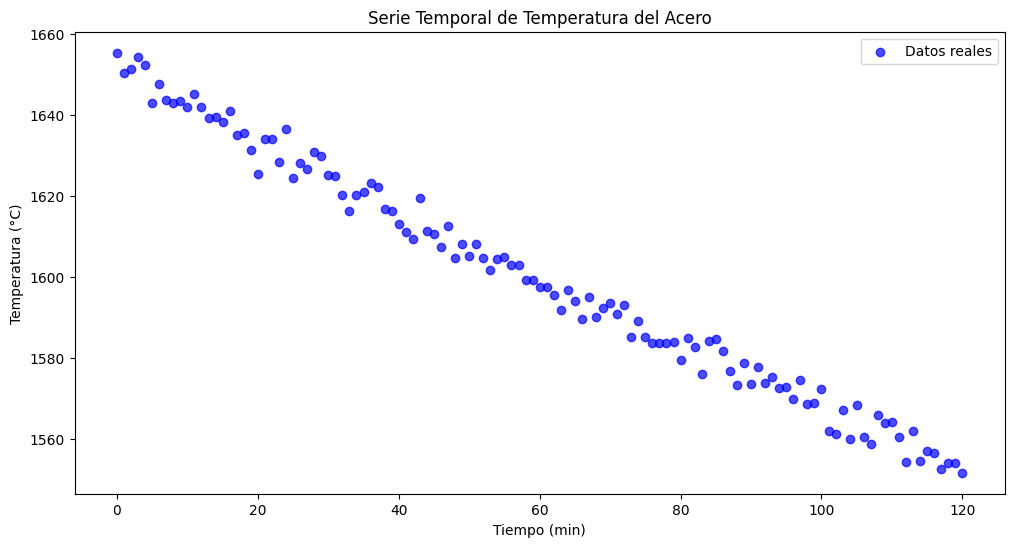

In [14]:
Data_reto_2 = pd.read_csv('./data/Reto_2/serie_temporal_acero.csv')

plt.figure(figsize=(12, 6))
plt.scatter(Data_reto_2['tiempo_min'], Data_reto_2['T_medida'], color='blue', label='Datos reales', alpha=0.7)
plt.title('Serie Temporal de Temperatura del Acero')
plt.xlabel('Tiempo (min)')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.show()

## ***Resolución analitica***

### Modelo físico (Ley de enfriamiento de Newton)

La ecuación diferencial ordinaria (EDO) para la temperatura del acero es:

$$
\frac{dT}{dt} = -k\,(T - T_{\text{amb}}), \qquad k>0 \tag{1}
$$

Donde:
- $T(t)$ es la temperatura del acero en el tiempo $t$.
- $T_{\text{amb}}$ es la temperatura ambiente (considerada constante).
- $k$ es la constante de enfriamiento.

Si imponemos la condición inicial $T(0)=T_0$, la resolución analítica por separación de variables es:

$$
\frac{dT}{T - T_{\text{amb}}} = -k\,dt \tag{2}
$$

$$
\int \frac{dT}{T - T_{\text{amb}}} = \int -k\,dt
\;\Rightarrow\;
\ln|T - T_{\text{amb}}| = -kt + C \tag{3}
$$

$$
T - T_{\text{amb}} = C_1 e^{-kt} \tag{4}
$$

Aplicando $T(0)=T_0$:

$$
C_1 = T_0 - T_{\text{amb}} \tag{5}
$$

Por tanto, la solución cerrada es:

$$
\boxed{T(t)=T_{\text{amb}} + (T_0 - T_{\text{amb}})e^{-kt}} \tag{6}
$$

Forma equivalente para predicción con variables del dataset:

$$
\boxed{T_{\text{final}} = T_{\text{amb}} + (T_{\text{inicial}}-T_{\text{amb}})e^{-k\,t_{\text{proceso}}}} \tag{7}
$$

Cuadro con forma útil:

$$
\boxed{\ln(T-T_{\text{amb}})-\ln(T_0-T_{\text{amb}})=-kt} \tag{8}
$$

## ***Estimación de k (expresion 7)***

In [15]:
# -----------------------------
# 1) Cargar datos
# -----------------------------
try:
    df = pd.read_csv('serie_temporal_acero.csv')  # columnas: tiempo_min, T_medida
except FileNotFoundError:
    df = pd.read_csv('./data/Reto_2/serie_temporal_acero.csv')  # fallback

tiempo = df['tiempo_min'].values
T_medida = df['T_medida'].values
T0 = T_medida[0]  # temperatura inicial
T_amb = 35.0      # temperatura ambiente constante

# -----------------------------
# 2) Modelo enfriamiento de Newton con T_amb constante
# -----------------------------
def modelo_newton(t, k):
    return T_amb + (T0 - T_amb) * np.exp(-k * t)

# -----------------------------
# 3) Ajustar parametro k
# -----------------------------
p0 = [5e-4]  # valor inicial para k

popt, _ = curve_fit(modelo_newton, tiempo, T_medida, p0=p0, bounds=(0, np.inf))
k_est = popt[0]

print(f'Parametro ajustado:\nk = {k_est:.4e} 1/min')
print(f'T_amb = {T_amb} C (constante)')

# -----------------------------
# 4) Prediccion
# -----------------------------
T_pred = modelo_newton(tiempo, k_est)

# -----------------------------
# 5) Guardar resultados
# -----------------------------
df_result = pd.DataFrame({
    'tiempo_min': tiempo,
    'T_medida': T_medida,
    'T_predicha': T_pred
})
df_result.to_csv('./csv_resume/predicciones.csv', index=False)
print('Archivo predicciones.csv generado correctamente.')

Parametro ajustado:
k = 5.6735e-04 1/min
T_amb = 35.0 C (constante)
Archivo predicciones.csv generado correctamente.


## ***Estimación de k (expresion 8)***

Estimacion inicial de alfa (linearizada): 5.266806e-04 1/min


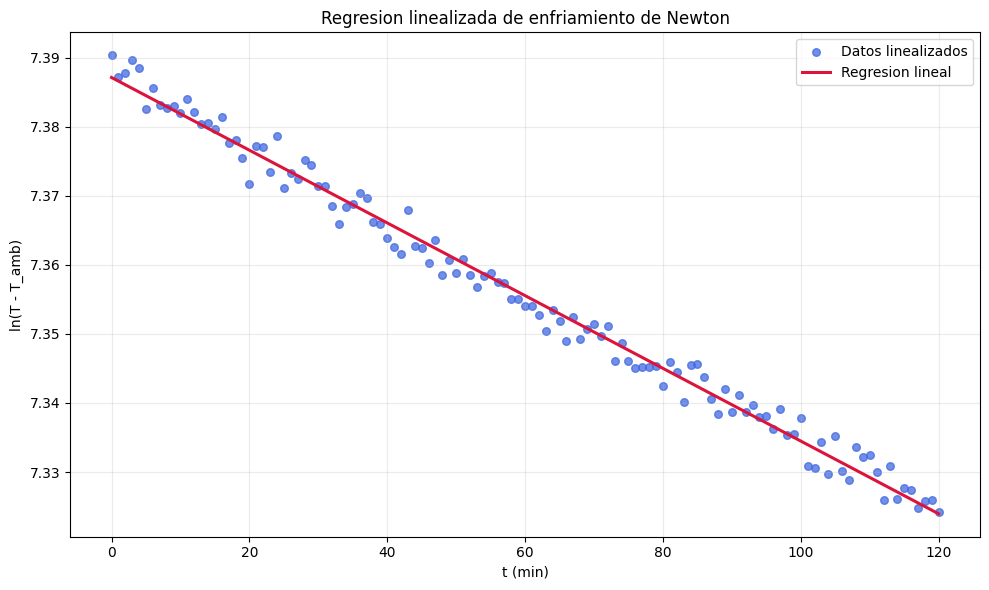

In [16]:
# -----------------------------
# 1) Cargar datos
# -----------------------------
df = pd.read_csv('./data/Reto_2/serie_temporal_acero.csv')  # columnas: tiempo_min, T_medida
t = df['tiempo_min'].values
T_obs = df['T_medida'].values

# -----------------------------
# 2) Parametros conocidos
# -----------------------------
T0 = T_obs[0]       # temperatura inicial
T_amb = 35.0        # temperatura ambiente fija

# -----------------------------
# 3) Linearizacion para estimacion inicial de alfa
# -----------------------------
Y = np.log(T_obs - T_amb)
X = t
coef = np.polyfit(X, Y, 1)    # ajuste lineal
alfa_init = -coef[0]          # pendiente = -alpha
print(f'Estimacion inicial de alfa (linearizada): {alfa_init:.6e} 1/min')

# -----------------------------
# 4) Grafica de la regresion linealizada
# -----------------------------
Y_fit = coef[0] * X + coef[1]

plt.figure(figsize=(10, 6))
plt.scatter(X, Y, s=30, alpha=0.75, color='royalblue', label='Datos linealizados')
plt.plot(X, Y_fit, color='crimson', linewidth=2.2, label='Regresion lineal')
plt.title('Regresion linealizada de enfriamiento de Newton')
plt.xlabel('t (min)')
plt.ylabel('ln(T - T_amb)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## ***Derivación de la Energía Mínima***

### ***Restricciones de temperatura***

Necesitamos que la temperatura de llegada al tundish esté dentro del rango operativo:

$$1515°\text{C} \leq T_{tundish} \leq 1560°\text{C}$$

Para **minimizar la energía** aplicada, debemos alcanzar la **temperatura mínima posible** del rango:

$$T(t_{transporte}) = 1515°\text{C}$$

---

### ***Solución de la EDO***

La ecuación diferencial ordinaria:

$$\frac{dT}{dt} = -k(T - T_{amb})$$

tiene solución general:

$$T(t) = C e^{-kt} + T_{amb}$$

donde $C$ es una constante de integración determinada por la condición inicial.

---

### ***Determinación de la constante C***

En el instante inicial ($t = 0$), la temperatura es $T_{salida}$ (temperatura tras los electrodos):

$$T(0) = C + T_{amb} = T_{salida}$$

Por lo tanto:

$$C = T_{salida} - T_{amb}$$

---

### ***Expresión de T al tiempo de transporte***

Sustituyendo la constante $C$ en la solución general:

$$T(t_{transporte}) = (T_{salida} - T_{amb}) e^{-k t_{transporte}} + T_{amb}$$

Despejando $T_{salida}$ (reagrupando términos):

$$T(t_{transporte}) - T_{amb} = (T_{salida} - T_{amb}) e^{-k t_{transporte}}$$

$$T_{salida} - T_{amb} = [T(t_{transporte}) - T_{amb}] e^{k t_{transporte}}$$

$$T_{salida} = [T(t_{transporte}) - T_{amb}] e^{k t_{transporte}} + T_{amb}$$

---

### ***Expresión de la energía requerida***

La energía eléctrica aplicada en los electrodos del horno cuchara es:

$$E = (T_{salida} - T_{cuchara}) \cdot \frac{m \cdot c_p}{\eta}$$

Sustituyendo la expresión de $T_{salida}$:

$$E = \left( [T(t_{transporte}) - T_{amb}] e^{k t_{transporte}} + T_{amb} - T_{cuchara} \right) \cdot \frac{m \cdot c_p}{\eta}$$

---

### ***Energía mínima***

Para minimizar energía, utilizamos $T(t_{transporte}) = 1515°\text{C}$:

$$\boxed{E_{min} = \left( [1515 - T_{amb}] e^{k t_{transporte}} + T_{amb} - T_{cuchara} \right) \cdot \frac{m \cdot c_p}{\eta}}$$

**Valores numéricos a utilizar:**
- $T_{amb} = 35°\text{C}$
- $T_{cuchara} = 1550°\text{C}$
- $k$ = valor calibrado en Parte A
- $t_{transporte} = 45$ min
- $m = 150,000$ kg
- $c_p = 2.326 \times 10^{-4}$ kWh/(kg·°C)
- $\eta = 0.72$

### ***Función que calcula el valor***

In [17]:
###
# Funciones
###

def T0(k, t=45, Tamb=35, T=1515):
    '''
    Calculo de la temperatura teorica inicial para llegar a la
    final con el valor minimo.

    Input:

        -k: constante que calculamos en a
        -t,Tamb,T: Valores del problema

    Output:

        -T0: Temperatura inicial necesitada para llegar al valor minimo (C)
    '''
    return np.exp(k * t) * (T - Tamb) + Tamb

def E(Tsal, Tcuch=1550, m=1.5e5, cp=2.326e-4, eta=0.72):
    '''
    Calculo de la energia que hay que aplicar para llegar a T0

    Input:

        -Tsal: Temperatura de entrada
        -Tcuch,m,cp,eta: parametros auxiliares del problema.

    Output:

        -Energia: Energia que hay que meter en kW h
    '''
    return ((m * cp) / eta) * (Tsal - Tcuch)

###
# Codigo
###
T0p = T0(5.3e-04)
print(f'La temperatura inicial minima es de {T0p} C')

Es = E(T0p)
print(f'La energia minima, por tanto, es de {Es} kW h')

La temperatura inicial minima es de 1550.7222950811292 C
La energia minima, por tanto, es de 35.00121580638738 kW h


# ***Ejercicio 3***

In [ ]:
'''
Este código simula la temperatura en distintos radios de la cuchara para 
distintos tiempos. Utiliza un método híbrido: Euler implicito+xgboost.

Se ha probado a utilizar otros métodos como Crank-Nicolson, Euler explícito,
o métodos más exóticos como el método de volumenes y método espectral, pero
este ha resultado el más estable al usarlo con xgboost.

A su vez, se ha estudiado el efecto de diversos modelos de ML en lugar de xgboost,
si bien un modelo de red neuronal simple parecía dar buenos resultados, los resultados
fueron en general más estables al realizar el modelo con xgboost.

Por último, se evalua el modelo usando un split 80-20 para estudiar ligeramente el 
efecto del overfitting, observamos que obtenemos el valor de un RMSE de 0.0124ºC en
el test, luego unos datos muy satisfactorios.
'''
###
#Imports
###


###
#Semilla
###
np.random.seed(3435) 

###
#Datos
###
#Importamos el fichero
try:
    df = pd.read_csv('./data/Reto_3/pde_data.csv')
except FileNotFoundError:
    print("Error: Archivo 'pde_data.csv' no encontrado.")
    exit()

#Datos físicos del problema
R_int, R_ext = 1.50, 1.80
lam, h_ext = 3.0, 15.0
T_ini, T_amb, T_ext_0, theta = 1650.0, 35.0, 350.0, 0.00053

#Preparamos los mallados temporales y espaciales, así como el número de puntos y 
#el dr.
t_nodes = np.sort(df['tiempo_min'].unique())
r_nodes = np.sort(df['radio_m'].unique())
Nt, Nr = len(t_nodes), len(r_nodes)
dr = r_nodes[1] - r_nodes[0]

#Split

df_train, df_test = train_test_split(df, test_size=0.20, random_state=34)

###
#Funciones
###

def T_acero(t_min):
    '''
    Temperatura del acero dentro de la cuchara, y por ende, en las paredes
    interiores.

    Inputs:

        -t_min: Tiempo en minutos

    Returns:

        -Temperatura del acero (ºC)
    '''
    return T_amb + (T_ini - T_amb) * np.exp(-theta * t_min)

def resolver_edp_euler_implicito(params):
    '''
    Resolutor de Euler Implícito para difusividad constante.

    Inputs:

        -params: alfa a tomar para la resolución

    Outputs:

        T_sim: Array con las temperaturas simuladas
    '''

    #Alfa a usar
    a0 = params[0]

    #Preparamos el array de iteración
    T_sim = np.zeros((Nt, Nr))
    
    #Condiciones iniciales, la temperatura es lineal de la pared de dentro a la de fuera

    T_sim[0, :] = T_ini + ((r_nodes - R_int) / (R_ext - R_int)) * (T_ext_0 - T_ini)

    r_inc = r_nodes[1:] 

    #Pasamos a minutos
    alpha_min = a0 * 60.0 
    
    for n in range(Nt - 1):
        #Salto temporal, nos interesa evaluar justo en los puntos del csv para tener una comparación
        #precisa y no una interpolación
        dt = t_nodes[n+1] - t_nodes[n]
        T_prev = T_sim[n, 1:]
        T_dir_next = T_acero(t_nodes[n+1])
        
        #Coeficientes
        A = (alpha_min * dt) / (dr**2)
        B = (alpha_min * dt) / (2 * r_inc * dr)
        
        d_main = (1 + 2 * A) * np.ones(len(r_inc))
        d_up = -(A + B[:-1])
        d_down = -(A - B[1:])
        
        d_main[-1] += 2 * A * (dr * h_ext / lam)

        #Matrices de euler implicito
        M = np.diag(d_main) + np.diag(d_up, 1) + np.diag(d_down, -1)
        M[-1, -2] = -2 * A 
        
        rhs = T_prev.copy()
        rhs[0] += (A - B[0]) * T_dir_next
        rhs[-1] += 2 * A * (dr * h_ext / lam) * T_amb
        
        #Resolvemos
        T_sim[n+1, 1:] = np.linalg.solve(M, rhs)
        T_sim[n+1, 0] = T_dir_next
        
    return T_sim

def funcion_coste(a0_s):
    '''
    Función de coste adaptada para recibir un escalar.
    Se castiga que el alfa no sea coherente, y en otro caso 
    se evalúa por su error cuadrático medio.

    Inputs:

        -a0_s: Valor de alfa

    Outputs:

        -Error cuadrático medio
    '''
    a0 = a0_s * 1e-6
    
    #Castigo a tope para si no es coherente el a0
    if a0 <= 0: return 1e9 
    
    #Calculamos la simulación
    T_sim = resolver_edp_euler_implicito((a0,))
    
    df_sim = pd.DataFrame({
        'tiempo_min': np.repeat(t_nodes, Nr),
        'radio_m': np.tile(r_nodes, Nt),
        'T_base': T_sim.flatten()
    })
    m = pd.merge(df_train, df_sim, on=['tiempo_min', 'radio_m'])
    return np.sqrt(mean_squared_error(m['T'], m['T_base']))

print("\n[Fase 1] Calibrando alpha con minimize_scalar (Brent Bounded)...")


# Usamos minimize_scalar con límites definidos
res = minimize_scalar(funcion_coste, bounds=(0.1, 10.0), method='bounded')

a0_opt = res.x * 1e-6
print(f"Alpha optimizado: {a0_opt:.4e}")

# Fase 2: XGBoost
T_fis = resolver_edp_euler_implicito((a0_opt,))

df_fis = pd.DataFrame({
    'tiempo_min': np.repeat(t_nodes, Nr),
    'radio_m': np.tile(r_nodes, Nt),
    'T_base': T_fis.flatten()
})

#Datasets de las estimaciones numéricas
ds_train = pd.merge(df_train, df_fis, on=['tiempo_min', 'radio_m'])
ds_test = pd.merge(df_test, df_fis, on=['tiempo_min', 'radio_m'])

#Sacamos la artillería pesada, xgboost para corregir nuestros errores
xgb_reg = xgb.XGBRegressor(n_estimators=1500, learning_rate=0.05, max_depth=6, subsample=0.7, random_state=42)
xgb_reg.fit(ds_train[['tiempo_min', 'radio_m']], ds_train['T'] - ds_train['T_base'])

# Evaluación
ds_test['T_hibrida'] = ds_test['T_base'] + xgb_reg.predict(ds_test[['tiempo_min', 'radio_m']])
rmse_f = np.sqrt(mean_squared_error(ds_test['T'], ds_test['T_base']))
rmse_h = np.sqrt(mean_squared_error(ds_test['T'], ds_test['T_hibrida']))

print("\n" + "="*50)
print(f"RMSE Física (Euler Implícito): {rmse_f:.4f} ºC")
print(f"RMSE Híbrido:                  {rmse_h:.4f} ºC")
print("="*50)


###
#Dataset
###

print("\n[Fase 3] Generando predicciones para el dataset completo...")

# 1. Copiamos el dataframe original y guardamos su índice para asegurar el orden
df_completo = df.copy()
df_completo['orden_original'] = df_completo.index

# 2. Cruzamos con la base física (que ya tiene los valores de T_base para todo el mallado)
ds_completo = pd.merge(df_completo, df_fis, on=['tiempo_min', 'radio_m'], how='left')

# 3. Restauramos el orden estricto y eliminamos la columna auxiliar
ds_completo = ds_completo.sort_values('orden_original').drop(columns=['orden_original'])

# 4. Generamos las predicciones del corrector XGBoost para TODOS los datos
residuos_totales = xgb_reg.predict(ds_completo[['tiempo_min', 'radio_m']])

# 5. Calculamos la T híbrida y sobrescribimos la columna 'T' original para calcar el formato
ds_completo['T'] = ds_completo['T_base'] + residuos_totales

# 6. Filtramos estrictamente las columnas originales
df_final = ds_completo[['tiempo_min', 'radio_m', 'T']]

# 7. Exportamos el CSV sin guardar el índice de Pandas
df_final.to_csv('./csv_resume/predicciones_completas.csv', index=False)
print("Archivo './csv_resume/predicciones_completas.csv' generado con éxito en el formato original.")


[Fase 1] Calibrando alpha con minimize_scalar (Brent Bounded)...
Alpha optimizado: 1.2636e-06

RMSE Física (Euler Implícito): 0.6349 ºC
RMSE Híbrido:                  0.0130 ºC

[Fase 3] Generando predicciones para el dataset completo...
Archivo 'predicciones_completas.csv' generado con éxito en el formato original.
